# Ukraine War Sentiment Analysis
Sentiment analysis on Reddit and YouTube comments related to the war in Ukraine, with a focus on changes corresponding to political events linked to Trump.


## 1. Import required libraries

In [14]:
import pandas as pd
import numpy as np
import re
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# NLP and Sentiment Analysis
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline
import torch

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Preprocessing
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("Setup completed!")

Setup completed!


## 2. Keywords definition and Utility Functions

In [16]:
# Keywords
ukraine_war_keywords = [
    # Core conflict terms
    "ukraine", "russia", "putin", "moscow", "kyiv", "kiev", "donbas", "donetsk", 
    "crimea", "invasion", "war", "frontline", "nato", "zelensky", "kremlin",
    "kherson", "mariupol", "kharkiv", "luhansk", "strike", "missile", "tank", 
    "artillery", "offensive", "defense", "sanctions", "ceasefire", "peace",

    # Additional relevant terms
    "humanitarian", "refugees", "aid", "weapons", "military", "conflict",
    "casualties", "civilian", "evacuation", "siege"
]

def contains_war_keywords(text, keywords=ukraine_war_keywords):
    """Check if the text contains at least a war-related keyword"""
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    return any(keyword.lower() in text_lower for keyword in keywords)

def preprocess_text(text):
    """Preprocessing of the text for sentiment analysis"""
    if pd.isna(text):
        return ""
 
    text = str(text).lower()
    
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    
    text = re.sub(r'u/\w+|r/\w+|@\w+', '', text)
    
    text = re.sub(r'[^\w\s.,!?-]', ' ', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def convert_to_datetime(timestamp_col):
    """Convert timestamp to datetime"""
    if pd.api.types.is_numeric_dtype(timestamp_col):
        # Unix timestamp
        dt = pd.to_datetime(timestamp_col, unit='s', errors='coerce')
    else:
        # String datetime
        dt = pd.to_datetime(timestamp_col, errors='coerce')
    
    if dt.dt.tz is not None:
        dt = dt.dt.tz_convert('UTC').dt.tz_localize(None)
    
    return dt

print("Utility functions defined!")

Utility functions defined!


## 3. Loading and Preprocessing Reddit Data

In [17]:
reddit_datasets = {
    'relevance': [
        'putin_rel_p.csv', 'putin_rel_u.csv', 'putin_rel_wn.csv',
        'russian_invasion_rel_p.csv', 'russian_invasion_rel_u.csv', 'russian_invasion_rel_wn.csv',
        'trump_rel_p.csv', 'trump_rel_u.csv', 'trump_rel_wn.csv',
        'trump_zelensky_rel_p.csv', 'trump_zelensky_rel_u.csv', 'trump_zelensky_rel_wn.csv',
        'war_ukraine_rel_p.csv', 'war_ukraine_rel_u.csv', 'war_ukraine_rel_wn.csv',
        'zelensky_rel_p.csv', 'zelensky_rel_u.csv', 'zelensky_rel_wn.csv'
    ]
}

def load_reddit_data(dataset_type):
    """Load and preprocess Reddit data"""
    dataframes = []
    files_to_load = reddit_datasets[dataset_type]
    
    for filename in files_to_load:
        try:
            df = pd.read_csv(f'data/{filename}')
            
            df['source_file'] = filename
            df['dataset_type'] = dataset_type
            df['search_term'] = filename.split('_')[0] if '_' in filename else 'unknown'
            
            dataframes.append(df)
            
        except FileNotFoundError:
            print(f"⚠ File not found: {filename}")
        except Exception as e:
            print(f"❌ Error {filename}: {e}")
    
    if not dataframes:
        return pd.DataFrame()
    
    # Merge
    reddit_data = pd.concat(dataframes, ignore_index=True)
    
    # Preprocessing dates
    reddit_data['comment_created_utc'] = convert_to_datetime(reddit_data['comment_created_utc'])
    reddit_data['post_created_utc'] = convert_to_datetime(reddit_data['post_created_utc'])
    
    # Filter by date
    start_date = pd.to_datetime('2024-09-01').tz_localize(None)
    end_date = pd.to_datetime('2025-07-01').tz_localize(None)
    
    reddit_data = reddit_data[
        (reddit_data['comment_created_utc'] >= start_date) & 
        (reddit_data['comment_created_utc'] <= end_date)
    ]
    
    # Filter by comment score >= 5
    reddit_data = reddit_data[reddit_data['comment_score'] >= 5]
    
    # Preprocessing text
    reddit_data['comment_body_clean'] = reddit_data['comment_body'].apply(preprocess_text)
    
    # Add flag for war related comments
    reddit_data['contains_war_keywords'] = reddit_data['comment_body_clean'].apply(contains_war_keywords)
    
    # Remove duplicates
    reddit_data = reddit_data.drop_duplicates(subset=['comment_body_clean'], keep='first')
    
    print(f"\n📊 Dataset Reddit {dataset_type} processed:")
    print(f"   - Total comments: {len(reddit_data)}")
    print(f"   - Comments with war keyword: {reddit_data['contains_war_keywords'].sum()}")
    print(f"   - Range date: {reddit_data['comment_created_utc'].min()} - {reddit_data['comment_created_utc'].max()}")
    
    return reddit_data

reddit_relevance = load_reddit_data('relevance')


📊 Dataset Reddit relevance processed:
   - Total comments: 211648
   - Comments with war keyword: 73124
   - Range date: 2024-09-01 11:25:52 - 2025-06-30 23:55:45


## 4. Load and Preprocessing Youtube Data

In [18]:
def load_youtube_data():
    """Load and preprocess YouTube data"""
    youtube_files = [
        'youtube_war_ukraine_comments_only_1.csv',
        'youtube_war_ukraine_comments_only_3.csv',
        'youtube_war_ukraine_comments_only_4.csv',
        'youtube_war_ukraine_comments_only_5.csv',
        'youtube_zelensky_trump_comments_only_1.csv',
        'youtube_zelensky_trump_comments_only_2.csv'
    ]

    dataframes = []
    
    for filename in youtube_files:
        try:
            df = pd.read_csv(f'data/{filename}')
            df['source_file'] = filename
            dataframes.append(df)
            
        except FileNotFoundError:
            print(f"⚠ File not found: {filename}")
        except Exception as e:
            print(f"❌ Error loading {filename}: {e}")
    
    if not dataframes:
        return pd.DataFrame()
    
    # Merge all YouTube dataframes
    youtube_data = pd.concat(dataframes, ignore_index=True)
    
    # Date preprocessing
    youtube_data['comment_published_at'] = convert_to_datetime(youtube_data['comment_published_at'])
    youtube_data['video_published_at'] = convert_to_datetime(youtube_data['video_published_at'])
    
    # Filter by date (September 1, 2024 - June 30, 2025)
    start_date = pd.to_datetime('2024-09-01').tz_localize(None)
    end_date = pd.to_datetime('2025-06-30').tz_localize(None)
    
    youtube_data = youtube_data[
        (youtube_data['comment_published_at'] >= start_date) & 
        (youtube_data['comment_published_at'] <= end_date)
    ]
    
    # YouTube data should already be filtered by score, but double-check
    if 'comment_like_count' in youtube_data.columns:
        youtube_data = youtube_data[youtube_data['comment_like_count'] >= 0]  # Keep all since they might already be filtered
    
    # Text preprocessing
    youtube_data['comment_text_clean'] = youtube_data['comment_text'].apply(preprocess_text)
    
    # Add flag for war-related keywords
    youtube_data['contains_war_keywords'] = youtube_data['comment_text_clean'].apply(contains_war_keywords)
    
    # Remove duplicates
    youtube_data = youtube_data.drop_duplicates(subset=['comment_text_clean'], keep='first')
    
    print(f"\n📊 YouTube dataset processed:")
    print(f"   - Total comments: {len(youtube_data)}")
    print(f"   - Comments with war-related keywords: {youtube_data['contains_war_keywords'].sum()}")
    print(f"   - Date range: {youtube_data['comment_published_at'].min()} - {youtube_data['comment_published_at'].max()}")
    
    return youtube_data

# Load YouTube data
youtube_data = load_youtube_data()


📊 YouTube dataset processed:
   - Total comments: 151185
   - Comments with war-related keywords: 57484
   - Date range: 2024-09-01 11:23:24 - 2025-06-29 23:56:11


## 5. Setup Model for Multi-level Sentiment Analysis


In [19]:
def setup_sentiment_models():
    """Initialize sentiment analysis models"""
    print("🤖 Initializing sentiment models...")
    
    try:
        # Faster model for all analyses
        model_name = "distilbert-base-uncased-finetuned-sst-2-english"
        
        sentiment_pipeline = pipeline(
            "sentiment-analysis",
            model=model_name,
            tokenizer=model_name,
            device=0 if torch.cuda.is_available() else -1,
            max_length=256,  # Reduced for speed
            truncation=True
        )
        
        print(f"✓ Model loaded: {model_name}")
        print(f"✓ Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
        
        return sentiment_pipeline
        
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

def analyze_sentiment_batch(texts, sentiment_pipeline, batch_size=64):
    """Analyze the sentiment of a list of texts in batches"""
    results = []
    
    # Filter out empty texts
    valid_texts = [text for text in texts if text and len(str(text).strip()) > 0]
    
    if not valid_texts:
        return []
    
    print(f"🔄 Analyzing sentiment for {len(valid_texts)} texts...")
    
    # Process in larger batches for speed
    for i in range(0, len(valid_texts), batch_size):
        batch = valid_texts[i:i+batch_size]
        
        try:
            batch_results = sentiment_pipeline(batch)
            results.extend(batch_results)
            
            if i % (batch_size * 5) == 0:  # Progress every 5 batches
                progress = min(100, (i + batch_size) / len(valid_texts) * 100)
                print(f"   Progress: {progress:.1f}%")
                
        except Exception as e:
            print(f"⚠ Error in batch {i}-{i+batch_size}: {e}")
            # Add neutral results for the failed batch
            results.extend([{'label': 'NEUTRAL', 'score': 0.5}] * len(batch))
    
    return results

def contains_entity_keywords(text, entity_keywords):
    """Check if the text contains keywords for a specific entity"""
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    return any(keyword.lower() in text_lower for keyword in entity_keywords)

# Keywords for specific entity analysis
entity_keywords = {
    'trump': ['trump', 'donald'],
    'zelensky': ['zelensky', 'zelenskyy', 'volodymyr', 'ukrainian president'],
    'peace': ['peace', 'ceasefire', 'negotiations', 'diplomacy', 'diplomatic', 'truce', 'end war', 'stop war']
}

# Keywords for pro/anti-war classification
war_stance_keywords = {
    'pro_peace': ['peace', 'ceasefire', 'negotiations', 'diplomacy', 'end war', 'stop war', 'stop fighting'],
    'pro_conflict': ['victory', 'fight', 'defeat', 'weapons', 'military aid', 'arms', 'combat']
}

# Initialize the model
sentiment_pipeline = setup_sentiment_models()

🤖 Initializing sentiment models...


Device set to use cpu


✓ Model loaded: distilbert-base-uncased-finetuned-sst-2-english
✓ Device: CPU


## 6. Sentiment Analysis

In [20]:
def extract_entity_contexts(text, entity_keywords, context_sentences=1):
    """
    Extract specific contexts around entity mentions based on sentences
    
    Args:
        text: Text to analyze
        entity_keywords: List of keywords for the entity
        context_sentences: Number of sentences before/after to include (default=1)
    
    Returns:
        List of extracted contexts
    """
    if pd.isna(text) or not text:
        return []
    
    text_original = str(text)
    text_lower = text_original.lower()
    
    # Split into sentences using multiple separators
    import re
    sentences = re.split(r'[.!?]+', text_original)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    if not sentences:
        return []
    
    contexts = []
    used_sentence_groups = set()  # Avoid duplicates
    
    # Search for keywords in each sentence
    for i, sentence in enumerate(sentences):
        sentence_lower = sentence.lower()
        
        # Check if the sentence contains entity keywords
        entity_found = any(keyword.lower() in sentence_lower for keyword in entity_keywords)
        
        if entity_found:
            # Determine start and end index of the context
            start_idx = max(0, i - context_sentences)
            end_idx = min(len(sentences), i + context_sentences + 1)
            
            # Create a unique key for this group of sentences
            context_key = (start_idx, end_idx)
            
            if context_key not in used_sentence_groups:
                # Extract the context (previous + current + next sentences)
                context_sentences_list = sentences[start_idx:end_idx]
                context = '. '.join(context_sentences_list).strip()
                
                # Add only if sufficiently long
                if len(context) > 15:
                    contexts.append(context)
                    used_sentence_groups.add(context_key)
    
    # Remove duplicates while preserving order
    unique_contexts = []
    seen = set()
    for context in contexts:
        context_lower = context.lower()
        if context_lower not in seen:
            unique_contexts.append(context)
            seen.add(context_lower)
    
    return unique_contexts


def analyze_entity_sentiment_contextual(text, entity_keywords, sentiment_pipeline, context_sentences=1):
    """
    Analyze sentiment towards a specific entity based on sentence context
    
    Args:
        text: Text to analyze
        entity_keywords: Keywords of the entity
        sentiment_pipeline: Sentiment analysis pipeline
        context_sentences: Number of sentences before/after to include in context
    
    Returns:
        Average numeric sentiment score towards the entity
    """
    contexts = extract_entity_contexts(text, entity_keywords, context_sentences)
    
    if not contexts:
        return None
    
    # Analyze sentiment for each context
    try:
        context_results = sentiment_pipeline(contexts)
        scores = []
        
        for result in context_results:
            label = result['label'].upper()
            score = result['score']
            
            # Convert into numeric score
            if label == 'POSITIVE':
                numeric_score = score
            elif label == 'NEGATIVE':
                numeric_score = -score
            else:
                numeric_score = 0
            
            scores.append(numeric_score)
        
        # Return the average sentiment across contexts
        return sum(scores) / len(scores) if scores else None
        
    except Exception as e:
        print(f"⚠ Error in contextual analysis: {e}")
        return None


def apply_contextual_sentiment_analysis(df, text_column, sentiment_pipeline):
    """
    Apply contextual sentiment analysis for specific entities
    """
    print(f"\n🎯 Applying contextual sentiment analysis...")
    
    # 1. GENERAL SENTIMENT (same as before, only on war-related comments)
    war_comments = df[df['contains_war_keywords']].copy()
    
    if war_comments.empty:
        print("❌ No comments with war-related keywords found!")
        for col in ['sentiment_label', 'sentiment_score', 'sentiment_normalized', 'sentiment_numeric',
                   'war_stance', 'trump_sentiment', 'zelensky_sentiment', 'peace_sentiment']:
            df[col] = None
        return df
    
    print(f"🔍 Found {len(war_comments)} comments with war-related keywords")
    
    # Initialize columns
    for col in ['sentiment_label', 'sentiment_score', 'sentiment_normalized', 'sentiment_numeric',
               'war_stance', 'trump_sentiment', 'zelensky_sentiment', 'peace_sentiment']:
        df[col] = None
    
    # General sentiment (unchanged)
    texts = war_comments[text_column].fillna('').tolist()
    sentiment_results = analyze_sentiment_batch(texts, sentiment_pipeline)
    
    if sentiment_results:
        war_indices = war_comments.index
        for i, result in enumerate(sentiment_results):
            if i < len(war_indices):
                idx = war_indices[i]
                label = result['label'].upper()
                score = result['score']
                
                df.loc[idx, 'sentiment_label'] = label
                df.loc[idx, 'sentiment_score'] = score
                
                if label == 'POSITIVE':
                    df.loc[idx, 'sentiment_normalized'] = 'positive'
                    df.loc[idx, 'sentiment_numeric'] = score
                elif label == 'NEGATIVE':
                    df.loc[idx, 'sentiment_normalized'] = 'negative'
                    df.loc[idx, 'sentiment_numeric'] = -score
                else:
                    df.loc[idx, 'sentiment_normalized'] = 'neutral'
                    df.loc[idx, 'sentiment_numeric'] = 0
    
    # 2. WAR STANCE (unchanged)
    print("🔄 Classifying pro/anti-war stance...")
    
    def classify_war_stance(text):
        if pd.isna(text):
            return 'neutral'
        
        text_lower = str(text).lower()
        pro_peace_count = sum(1 for kw in war_stance_keywords['pro_peace'] if kw in text_lower)
        pro_conflict_count = sum(1 for kw in war_stance_keywords['pro_conflict'] if kw in text_lower)
        
        if pro_peace_count > pro_conflict_count:
            return 'pro_peace'
        elif pro_conflict_count > pro_peace_count:
            return 'pro_conflict'
        else:
            return 'neutral'
    
    df.loc[df['contains_war_keywords'], 'war_stance'] = df.loc[df['contains_war_keywords'], text_column].apply(classify_war_stance)
    
    # 3. CONTEXTUAL SENTIMENT ON SPECIFIC ENTITIES (NEW!)
    print("🔄 Analyzing contextual sentiment on specific entities...")
    
    for entity, keywords in entity_keywords.items():
        print(f"   Processing {entity} (contextual)...")
        
        # Find comments mentioning the entity
        entity_mask = df[text_column].apply(lambda x: contains_entity_keywords(x, keywords))
        entity_comments = df[entity_mask]
        
        if len(entity_comments) > 0:
            print(f"     Found {len(entity_comments)} comments about {entity}")
            
            column_name = f'{entity}_sentiment'
            
            # Contextual analysis for each comment
            for idx in entity_comments.index:
                text = df.loc[idx, text_column]
                contextual_score = analyze_entity_sentiment_contextual(
                    text, keywords, sentiment_pipeline, context_sentences=1
                )
                df.loc[idx, column_name] = contextual_score
            
            # Statistics
            valid_scores = df.loc[entity_comments.index, column_name].dropna()
            if len(valid_scores) > 0:
                avg_sentiment = valid_scores.mean()
                print(f"     Average sentiment for {entity}: {avg_sentiment:.3f}")
        else:
            print(f"     No comments found for {entity}")
    
    print("✅ Contextual sentiment analysis completed!")
    return df

if not reddit_relevance.empty:
    print("📊 Processing Reddit RELEVANCE (multi-level)...")
    reddit_relevance = apply_contextual_sentiment_analysis(reddit_relevance, 'comment_body_clean', sentiment_pipeline)

if not youtube_data.empty:
    print("📊 Processing YouTube (multi-level)...")
    youtube_data = apply_contextual_sentiment_analysis(youtube_data, 'comment_text_clean', sentiment_pipeline)

📊 Processing Reddit RELEVANCE (multi-level)...

🎯 Applying contextual sentiment analysis...
🔍 Found 73124 comments with war-related keywords
🔄 Analyzing sentiment for 73124 texts...
   Progress: 0.1%
   Progress: 0.5%
   Progress: 1.0%
   Progress: 1.4%
   Progress: 1.8%
   Progress: 2.3%
   Progress: 2.7%
   Progress: 3.2%
   Progress: 3.6%
   Progress: 4.0%
   Progress: 4.5%
   Progress: 4.9%
   Progress: 5.3%
   Progress: 5.8%
   Progress: 6.2%
   Progress: 6.7%
   Progress: 7.1%
   Progress: 7.5%
   Progress: 8.0%
   Progress: 8.4%
   Progress: 8.8%
   Progress: 9.3%
   Progress: 9.7%
   Progress: 10.2%
   Progress: 10.6%
   Progress: 11.0%
   Progress: 11.5%
   Progress: 11.9%
   Progress: 12.3%
   Progress: 12.8%
   Progress: 13.2%
   Progress: 13.7%
   Progress: 14.1%
   Progress: 14.5%
   Progress: 15.0%
   Progress: 15.4%
   Progress: 15.8%
   Progress: 16.3%
   Progress: 16.7%
   Progress: 17.2%
   Progress: 17.6%
   Progress: 18.0%
   Progress: 18.5%
   Progress: 18.9%
   Pr

## 7. Explorative analysis of results

In [ ]:
# IF YOU DO NOT START FROM THE BEGINNING, BUT YOU USE THE DATASET WITH SENTIMENT (also the chunk below)
import pandas as pd
reddit_relevance = pd.read_csv("results/reddit_relevance_with_sentiment.csv")
youtube_data = pd.read_csv("results/youtube_with_sentiment.csv")

In [34]:
reddit_relevance_cut = reddit_relevance[reddit_relevance["comment_created_utc"] >= "2025-02-01"]
youtube_data_cut = youtube_data[youtube_data["comment_published_at"] >= "2025-02-01"]

In [ ]:
def explore_multilevel_sentiment_results(df, dataset_name):
    """Explore the results of the multi-level sentiment analysis"""
    print(f"\n📈 MULTI-LEVEL SENTIMENT ANALYSIS - {dataset_name}")
    print("=" * 60)
    
    if df.empty:
        print("❌ Empty dataset")
        return
    
    # Comments with calculated sentiment
    sentiment_comments = df.dropna(subset=['sentiment_numeric'])
    war_comments = df[df['contains_war_keywords']]
    
    print(f"📊 GENERAL STATISTICS:")
    print(f"   Total comments: {len(df):,}")
    print(f"   With war-related keywords: {len(war_comments):,} ({len(war_comments)/len(df)*100:.1f}%)")
    print(f"   With calculated sentiment: {len(sentiment_comments):,}")
    
    if len(sentiment_comments) == 0:
        print("❌ No sentiment calculated")
        return
    
    # 1. GENERAL WAR SENTIMENT
    print(f"\n⚔️ GENERAL WAR SENTIMENT:")
    sentiment_dist = sentiment_comments['sentiment_normalized'].value_counts(normalize=True)
    for sentiment, pct in sentiment_dist.items():
        print(f"   {sentiment.capitalize()}: {pct:.2%}")
    
    overall_sentiment = sentiment_comments['sentiment_numeric'].mean()
    print(f"   Average score: {overall_sentiment:.3f}")
    
    # 2. PRO/ANTI-WAR CLASSIFICATION
    stance_comments = df.dropna(subset=['war_stance'])
    if len(stance_comments) > 0:
        print(f"\n🎯 PRO/ANTI-WAR CLASSIFICATION:")
        stance_dist = stance_comments['war_stance'].value_counts(normalize=True)
        for stance, pct in stance_dist.items():
            print(f"   {stance.replace('_', ' ').title()}: {pct:.2%}")
    
    # 3. SENTIMENT TOWARDS SPECIFIC ENTITIES
    print(f"\n👥 SENTIMENT TOWARDS SPECIFIC ENTITIES:")
    
    for entity in ['trump', 'zelensky', 'peace']:
        entity_col = f'{entity}_sentiment'
        entity_comments = df.dropna(subset=[entity_col])
        
        if len(entity_comments) > 0:
            avg_sentiment = entity_comments[entity_col].mean()
            pos_count = (entity_comments[entity_col] > 0.1).sum()
            neg_count = (entity_comments[entity_col] < -0.1).sum()
            neu_count = len(entity_comments) - pos_count - neg_count
            
            print(f"   {entity.title()}:")
            print(f"      Comments: {len(entity_comments):,}")
            print(f"      Average score: {avg_sentiment:.3f}")
            print(f"      Distribution: {pos_count} pos, {neu_count} neu, {neg_count} neg")
        else:
            print(f"   {entity.title()}: No comments found")
    
    # 4. INTERESTING CORRELATIONS
    print(f"\n🔗 CORRELATIONS:")
    
    # Correlation general sentiment vs entity sentiment
    for entity in ['trump', 'zelensky', 'peace']:
        entity_col = f'{entity}_sentiment'
        common_comments = df.dropna(subset=['sentiment_numeric', entity_col])
        
        if len(common_comments) > 10:
            correlation = common_comments['sentiment_numeric'].corr(common_comments[entity_col])
            print(f"   War Sentiment vs {entity.title()}: {correlation:.3f}")
    
    print("\n" + "=" * 60)

# Explore results for each dataset
explore_multilevel_sentiment_results(reddit_relevance, "REDDIT RELEVANCE") 
explore_multilevel_sentiment_results(youtube_data, "YOUTUBE")


📈 MULTI-LEVEL SENTIMENT ANALYSIS - REDDIT RELEVANCE
📊 GENERAL STATISTICS:
   Total comments: 211,648
   With war-related keywords: 73,124 (34.5%)
   With calculated sentiment: 73,124

⚔️ GENERAL WAR SENTIMENT:
   Negative: 76.70%
   Positive: 23.30%
   Average score: -0.527

🎯 PRO/ANTI-WAR CLASSIFICATION:
   Neutral: 85.30%
   Pro Conflict: 8.84%
   Pro Peace: 5.85%

👥 SENTIMENT TOWARDS SPECIFIC ENTITIES:
   Trump:
      Comments: 38,444
      Average score: -0.493
      Distribution: 9031 pos, 878 neu, 28535 neg
   Zelensky:
      Comments: 6,375
      Average score: -0.339
      Distribution: 2017 pos, 120 neu, 4238 neg
   Peace:
      Comments: 5,535
      Average score: -0.442
      Distribution: 1455 pos, 114 neu, 3966 neg

🔗 CORRELATIONS:
   War Sentiment vs Trump: 0.763
   War Sentiment vs Zelensky: 0.828
   War Sentiment vs Peace: 0.759


📈 MULTI-LEVEL SENTIMENT ANALYSIS - YOUTUBE
📊 GENERAL STATISTICS:
   Total comments: 151,185
   With war-related keywords: 57,484 (38.0%)
   

📈 MULTI-LEVEL SENTIMENT ANALYSIS - REDDIT RELEVANCE

============================================================

📊 GENERAL STATISTICS:

   Total comments: 211,648

   With war-related keywords: 73,124 (34.5%)

   With calculated sentiment: 73,124

⚔️ GENERAL WAR SENTIMENT:

   Negative: 76.70%

   Positive: 23.30%

   Average score: -0.527

🎯 PRO/ANTI-WAR CLASSIFICATION:

   Neutral: 85.30%

   Pro Conflict: 8.84%

   Pro Peace: 5.85%

👥 SENTIMENT TOWARDS SPECIFIC ENTITIES:

   Trump:

      Comments: 38,444

      Average score: -0.493

      Distribution: 9031 pos, 878 neu, 28535 neg

   Zelensky:

      Comments: 6,375

      Average score: -0.339

      Distribution: 2017 pos, 120 neu, 4238 neg

   Peace:

      Comments: 5,535

      Average score: -0.442

      Distribution: 1455 pos, 114 neu, 3966 neg

🔗 CORRELATIONS:

   War Sentiment vs Trump: 0.763

   War Sentiment vs Zelensky: 0.828

   War Sentiment vs Peace: 0.759

============================================================

📈 MULTI-LEVEL SENTIMENT ANALYSIS - YOUTUBE

============================================================

📊 GENERAL STATISTICS:

   Total comments: 151,185

   With war-related keywords: 57,484 (38.0%)

   With calculated sentiment: 57,484

⚔️ GENERAL WAR SENTIMENT:

   Negative: 65.20%

   Positive: 34.80%

   Average score: -0.297

🎯 PRO/ANTI-WAR CLASSIFICATION:

   Neutral: 85.73%

   Pro Conflict: 7.55%

   Pro Peace: 6.72%

👥 SENTIMENT TOWARDS SPECIFIC ENTITIES:

   Trump:

      Comments: 17,666

      Average score: -0.379

      Distribution: 5243 pos, 194 neu, 12229 neg

   Zelensky:

      Comments: 12,292

      Average score: -0.361

      Distribution: 3775 pos, 139 neu, 8378 neg

   Peace:

      Comments: 4,735

      Average score: -0.191

      Distribution: 1879 pos, 60 neu, 2796 neg

🔗 CORRELATIONS:

   War Sentiment vs Trump: 0.844

   War Sentiment vs Zelensky: 0.881

   War Sentiment vs Peace: 0.852

============================================================

## Plot most frequent words

In [ ]:

import re
import string
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt


def plot_top_words_trump_zelensky(
    csv_path="reddit_relevance_with_sentiment.csv",
    top_n=20,
    extra_stopwords=None
):
    """
    Reads the dataset, separates comments related to Trump and Zelensky,
    computes most frequent words and shows a single horizontal bar chart
    with percentages (Trump in red, Zelensky in green).
    """

    # 1) Load dataset
    df = pd.read_csv(csv_path)

    # 2) Detect text column
    candidate_text_cols = ["body", "comment_body", "comment_text", "text", "content", "message"]
    text_col = next((c for c in candidate_text_cols if c in df.columns), None)
    if text_col is None:
        raise KeyError(f"No text column found. Available: {list(df.columns)}")

    # 3) Detect sentiment columns
    def find_sent_col(df, keyword_variants):
        lowered = {c.lower(): c for c in df.columns}
        for k_lower, orig in lowered.items():
            if any(kw in k_lower for kw in keyword_variants) and "sentiment" in k_lower:
                return orig
        return None

    trump_col = find_sent_col(df, ["trump", "donald"]) or "trump_sentiment"
    zel_col   = find_sent_col(df, ["zelensk", "zelensky", "zelenskyy", "volodymyr"]) or "zelensky_sentiment"

    if trump_col not in df.columns:
        raise KeyError("Trump sentiment column not found.")
    if zel_col not in df.columns:
        raise KeyError("Zelensky sentiment column not found.")

    # 4) Filter groups
    df_trump = df[df[trump_col].notna()]
    df_zel   = df[df[zel_col].notna()]

    # 5) Tokenization and cleaning
    base_stopwords = {
        "the","a","an","and","or","for","of","to","in","on","at","is","are","be","was","were","it","this","that","with",
        "as","by","from","but","not","we","you","they","i","he","she","them","his","her","our","their","your","my",
        "so","if","because","about","into","over","after","before","between","out","up","down","just","also","than",
        "too","very","can","could","should","would","will","what","which","who","whom","when","where","why","how",
        "me","us","him","hers","theirs","ours","yours","its","im","dont","doesnt","didnt","cant","wont","isnt","arent",
        "http","https","www","com", "have", "all", "has", "like", "no", "do", "it's", "been", "going", "only", "he's",
        "then", "any", "more", "even", "now", "said", "there", "think", "being", "gt", "one", "get", "had", "don't",
        "some", "know", "trump's", "see", "make", "much", "want", "did", "back", "say", "never", "years", "still",
        "thing", "could", "most", "wants", "first", "actually", "while", "wants", "doesn't", "other", "really"
    }
    subject_words = {"trump","donald","realdonaldtrump","potus",
                     "zelensky","zelenskyy","zelenskiy","volodymyr","presidentzelensky"}
    if extra_stopwords:
        base_stopwords |= {w.lower() for w in extra_stopwords}

    word_re = re.compile(r"[a-zA-ZÀ-ÖØ-öø-ÿ']+")

    def normalize_text(s: str) -> list[str]:
        if not isinstance(s, str):
            return []
        s = s.lower()
        s = re.sub(r"https?://\S+|www\.\S+", " ", s)
        s = re.sub(r"[@#]\w+", " ", s)
        tokens = word_re.findall(s)
        clean = [
            t.strip(string.punctuation).strip("'")
            for t in tokens
            if len(t.strip(string.punctuation).strip("'")) >= 2
        ]
        clean = [t for t in clean if t not in base_stopwords and t not in subject_words]
        return clean

    def top_words(series_text):
        counter = Counter()
        for txt in series_text:
            counter.update(normalize_text(txt))
        total = sum(counter.values())
        if total == 0:
            return {}
        return {w: c / total * 100 for w, c in counter.most_common()}

    # 6) Compute top words (percentages)
    perc_trump = top_words(df_trump[text_col].fillna(""))
    perc_zel   = top_words(df_zel[text_col].fillna(""))

    # 7) Select top_n words overall (based on max percentage between Trump and Zelensky)
    all_words = set(list(perc_trump.keys()) + list(perc_zel.keys()))
    sorted_words = sorted(
        all_words,
        key=lambda w: max(perc_trump.get(w, 0), perc_zel.get(w, 0)),
        reverse=True
    )[:top_n]

    # Values
    trump_vals = [perc_trump.get(w, 0) for w in sorted_words]
    zel_vals   = [perc_zel.get(w, 0) for w in sorted_words]

    # 8) Plot
    y = range(len(sorted_words))
    bar_height = 0.4

    plt.figure(figsize=(10, max(6, len(sorted_words) * 0.5)))
    plt.barh([i - bar_height/2 for i in y], zel_vals, height=bar_height, color="green", alpha=0.7, label="Zelensky")
    plt.barh([i + bar_height/2 for i in y], trump_vals, height=bar_height, color="red", alpha=0.7, label="Trump")

    plt.yticks(y, sorted_words)
    plt.xlabel("Relative frequency (%)")
    plt.title(f"Most Frequent Words in Trump vs. Zelensky Reddit Comments (Top {top_n})")
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()



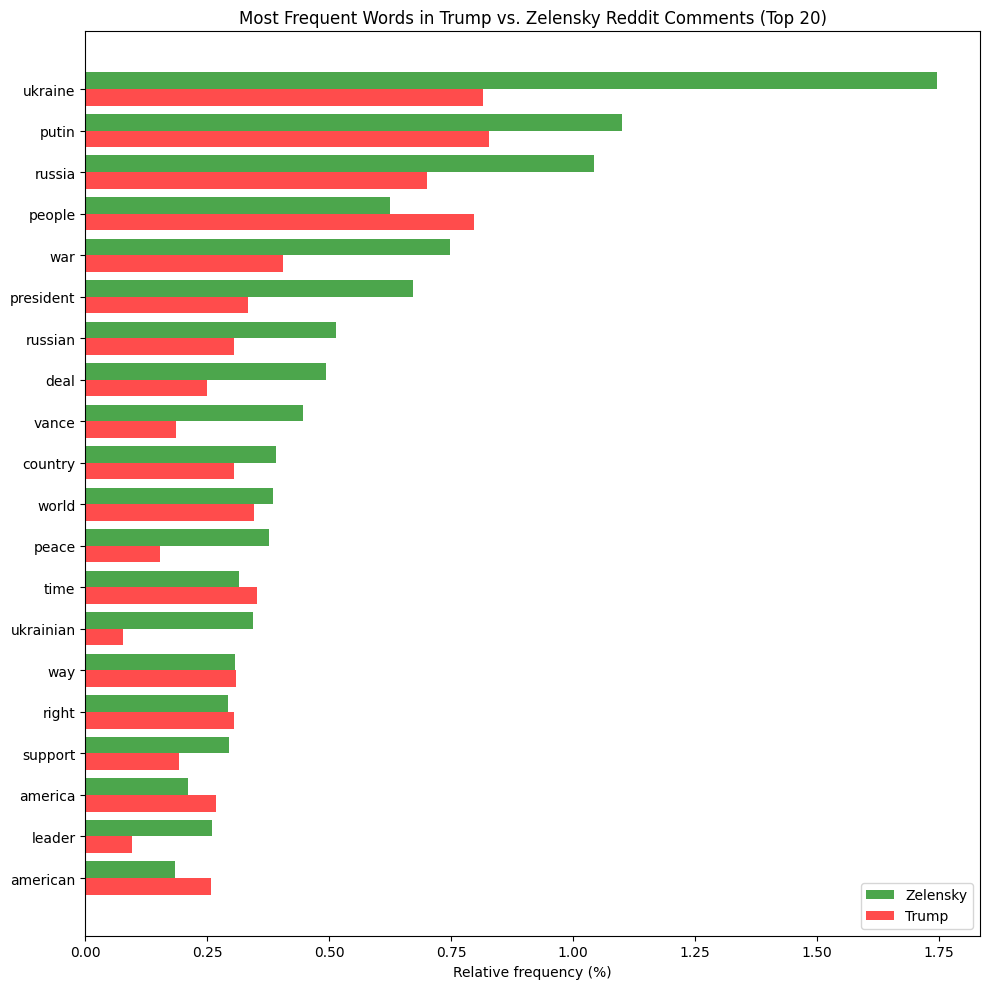

In [2]:
plot_top_words_trump_zelensky("reddit_relevance_with_sentiment.csv", top_n=20)

## 8. Time Series Sentiment

In [36]:
# FUNCTIONS FOR TIMELINE SENTIMENT ANALYSIS

def prepare_sentiment_timeline_data(df, date_column, sentiment_column):
    """
    Prepare data for timeline analysis for ONE SINGLE sentiment
    
    Args:
        df: DataFrame with the data
        date_column: Name of the date column
        sentiment_column: Name of the sentiment column to analyze
    
    Returns:
        DataFrame with daily statistics
    """
    
    # Ensure the date column is datetime
    df[date_column] = pd.to_datetime(df[date_column])
    
    # Filter only rows with valid values for this sentiment
    valid_data = df[df[sentiment_column].notna()].copy()
    
    if len(valid_data) == 0:
        print(f"     ⚠ No data for {sentiment_column}")
        return pd.DataFrame()
    
    # Group by date and calculate stats (only days with data)
    daily_stats = valid_data.groupby(valid_data[date_column].dt.date).agg({
        sentiment_column: ['mean', 'count', 'std']
    }).round(4)
    
    # Flatten column names
    daily_stats.columns = ['sentiment_mean', 'comment_count', 'sentiment_std']
    daily_stats = daily_stats.reset_index()
    daily_stats[date_column] = pd.to_datetime(daily_stats[date_column])

    # Calculate trend ±3 days (centered rolling average) WEIGHTED by number of comments
    daily_stats = daily_stats.sort_values(date_column)
    weighted_sum = (daily_stats['sentiment_mean'] * daily_stats['comment_count']).rolling(
        window=3, center=True, min_periods=2
    ).sum()
    weight_sum = daily_stats['comment_count'].rolling(
        window=3, center=True, min_periods=2
    ).sum()
    daily_stats['sentiment_trend'] = weighted_sum / weight_sum
    
    print(f"     ✓ {len(daily_stats)} days with data")
    return daily_stats


def create_complete_timeline(df, date_column, sentiment_column, start_date, end_date):
    """
    Create COMPLETE timeline with all days (even without comments) for numerical analysis
    
    Args:
        df: Original DataFrame
        date_column: Name of the date column
        sentiment_column: Name of the sentiment column
        start_date: Start date of the period
        end_date: End date of the period
    
    Returns:
        DataFrame with all days in the period
    """
    # Ensure date is datetime
    df[date_column] = pd.to_datetime(df[date_column])
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    # Create full date range
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    complete_timeline = pd.DataFrame({date_column: date_range})
    
    # Filter only rows with valid values
    valid_data = df[df[sentiment_column].notna()].copy()
    
    # Group by date and calculate stats
    daily_stats = valid_data.groupby(valid_data[date_column].dt.date).agg({
        sentiment_column: ['mean', 'count', 'std']
    }).round(4)
    
    # Flatten column names
    daily_stats.columns = ['sentiment_mean', 'comment_count', 'sentiment_std']
    daily_stats = daily_stats.reset_index()
    daily_stats[date_column] = pd.to_datetime(daily_stats[date_column])
    
    # Merge with complete timeline (left join keeps all days)
    complete_timeline = complete_timeline.merge(daily_stats, on=date_column, how='left')
    
    # Fill NaN for days without comments with 0 comments
    complete_timeline['comment_count'] = complete_timeline['comment_count'].fillna(0)
    
    return complete_timeline


def create_event_windows(events_dict, window_days=3):
    """
    Create time windows ±window_days for each event
    
    Args:
        events_dict: Dict with events {name: date}
        window_days: Days before/after the event (default: 3)
    
    Returns:
        Dict with windows {name: (start_date, event_date, end_date)}
    """
    event_windows = {}
    
    for event_name, event_date in events_dict.items():
        if isinstance(event_date, str):
            event_date = pd.to_datetime(event_date)
        
        before_start = event_date - timedelta(days=window_days)
        before_end = event_date - timedelta(days=1)
        after_start = event_date
        after_end = event_date + timedelta(days=window_days)
        event_windows[event_name] = {
            'event': event_date,
            'before_start': before_start,
            'before_end': before_end, 
            'after_start': after_start,
            'after_end': after_end
        }
    
    return event_windows


def plot_single_sentiment_timeline(timeline_data, events_dict, date_column, 
                                 sentiment_name, color, title, figsize=(15, 8)):
    """
    Create a CLEAN SINGLE timeline plot for a specific sentiment
    
    Args:
        timeline_data: DataFrame with prepared data (only days with ≥3 comments for visualization)
        events_dict: Dict of events
        date_column: Name of the date column
        sentiment_name: Name of the sentiment (for labels)
        color: Plot color
        title: Title of the chart
        figsize: Figure size
    
    Returns:
        Matplotlib figure and numbered event list
    """
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from datetime import datetime
    
    # Create event windows (±3 days)
    event_windows = create_event_windows(events_dict, window_days=3)
    
    # Setup figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.suptitle(f'{title}', 
                 fontsize=16, fontweight='bold')
    
    if timeline_data.empty:
        ax.text(0.5, 0.5, f'No data available for {sentiment_name}', 
               ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(title, fontsize=14, pad=20)
        return fig, []
    
    # Filter only days with ≥3 comments for the chart
    filtered_data = timeline_data[timeline_data['comment_count'] >= 3].copy()
    
    if filtered_data.empty:
        ax.text(0.5, 0.5, f'No days with ≥3 comments for {sentiment_name}', 
               ha='center', va='center', transform=ax.transAxes, fontsize=14)
        return fig, []
    
    # Plot daily data (thin line)
    ax.plot(filtered_data[date_column], filtered_data['sentiment_mean'], 
           color=color, alpha=0.6, linewidth=1.5, 
           label='Daily Sentiment')
    
    # Plot ±3 day trend (thicker line) - only if available
    valid_trend = filtered_data.dropna(subset=['sentiment_trend'])
    if not valid_trend.empty:
        ax.plot(valid_trend[date_column], valid_trend['sentiment_trend'],
               color=color, linewidth=3, alpha=0.9,
               label='Trend (±3 days)')
    
    # Zero line
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Add ONLY event lines (numbered)
    event_list = []
    for i, (event_name, window) in enumerate(event_windows.items(), 1):
        # Event line
        ax.axvline(window['event'], color='grey', linestyle='--', 
                  linewidth=2, alpha=0.8)
        
        # Event number (without full name)
        ax.annotate(str(event_name[0]), 
                   xy=(window['event'], ax.get_ylim()[1]), 
                   xytext=(0, -10),
                   textcoords='offset points',
                   bbox=dict(boxstyle='circle,pad=0.3', fc='grey', alpha=0.7),
                   fontsize=10, ha='center', fontweight='bold',
                   color='white')
        
        event_list.append(f"{i} = {event_name}")
    
    # Axis config
    ax.set_ylabel('Sentiment Score\n(-1=Negative, +1=Positive)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=11)
    
    # X axis format
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator())
    
    # Rotate labels
    plt.xticks(rotation=45)
    
    # Optimized layout
    plt.tight_layout()
    plt.savefig(f"results/{title}.png")
    
    return fig, event_list


def analyze_single_sentiment_impact(df, events_dict, date_column, sentiment_column,
                                  sentiment_name, window_days=3):
    """
    Analyze the numerical impact of events on ONE SINGLE sentiment
    USES ALL DAYS (even without comments) for more accurate calculations
    
    Args:
        df: ORIGINAL DataFrame (not timeline_data!)
        events_dict: Dict of events
        date_column: Name of the date column
        sentiment_column: Name of the sentiment column
        sentiment_name: Sentiment name for output
        window_days: Window in days (default: 3)
    
    Returns:
        Dict with impact results
    """
    print(f"\n📈 EVENT IMPACT ANALYSIS - {sentiment_name.upper()}")
    print("=" * 50)
    
    # Convert sentiment_column to numeric to avoid errors
    df = df.copy()
    df[sentiment_column] = pd.to_numeric(df[sentiment_column], errors='coerce')
    
    # Filter only rows with valid values
    valid_data = df[df[sentiment_column].notna()].copy()
    
    if valid_data.empty:
        print("❌ No valid data available")
        return {}
    
    # Ensure date column is datetime
    valid_data[date_column] = pd.to_datetime(valid_data[date_column])
    if hasattr(valid_data[date_column].dtype, 'tz') and valid_data[date_column].dt.tz is not None:
        valid_data[date_column] = valid_data[date_column].dt.tz_localize(None)
    

    event_windows = create_event_windows(events_dict, window_days)
    results = {}
    
    for event_name, window in event_windows.items():
        print(f"   {event_name} ({window['event'].strftime('%Y-%m-%d')}):")
        
        # Filter data ±3 days from event
        before_data = valid_data[
            (valid_data[date_column] >= window['before_start']) & 
            (valid_data[date_column] <= window['before_end'])
        ]
        
        after_data = valid_data[
            (valid_data[date_column] >= window['after_start']) & 
            (valid_data[date_column] <= window['after_end'])
        ]
        
        if len(before_data) < 5 or len(after_data) < 5:
            print(f"     ⚠ Insufficient data (Before: {len(before_data)}, After: {len(after_data)})")
            continue
        
        pre_avg = before_data[sentiment_column].mean()
        post_avg = after_data[sentiment_column].mean()
        change = post_avg - pre_avg
        
        # Statistical test (t-test)
        from scipy.stats import ttest_ind
        try:
            t_stat, p_value = ttest_ind(before_data[sentiment_column], 
                                      after_data[sentiment_column])
            significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        except:
            t_stat, p_value, significance = None, None, ""
        
        print(f"     Pre-event:  {pre_avg:+.3f} ({len(before_data)} comments)     Post-event: {post_avg:+.3f} ({len(after_data)} comments)")
        print(f"     Change:     {change:+.3f} {'📈' if change > 0 else '📉' if change < 0 else '➖'} {significance}")
        
        results[event_name] = {
            'pre': pre_avg,
            'post': post_avg,
            'change': change,
            'pre_count': len(before_data),
            'post_count': len(after_data),
            'p_value': p_value,
            'significance': significance
        }
    
    return results

# KEY EVENTS
key_events = {
    '1) Trump elected' : '2024-11-07',
    '2) Trump inauguration' : '2025-01-20', 
    '3) Trump calls Putin': '2025-02-12',
    '4) Trump-Zelensky-Vance meeting' : '2025-02-28',
    '5) Suspension of military aid' : '2025-03-03',
    '6) 30-day ceasefire + aid restored' : '2025-03-11',
    '7) Trump-Zelensky meeting (Pope funeral)' : '2025-04-26',
    '8) Second Trump-Putin call' : '2025-05-19'
}

# KEY EVENTS (subset)
key_events2 = {
    '3) Trump calls Putin': '2025-02-12',
    '4) Trump-Zelensky-Vance meeting' : '2025-02-28',
    '5) Suspension of military aid' : '2025-03-03',
    '6) 30-day ceasefire + aid restored' : '2025-03-11',
    '7) Trump-Zelensky meeting (Pope funeral)' : '2025-04-26',
    '8) Second Trump-Putin call' : '2025-05-19'
}

🎯 CHART 1: Reddit - War Sentiment
     ✓ 298 days with data


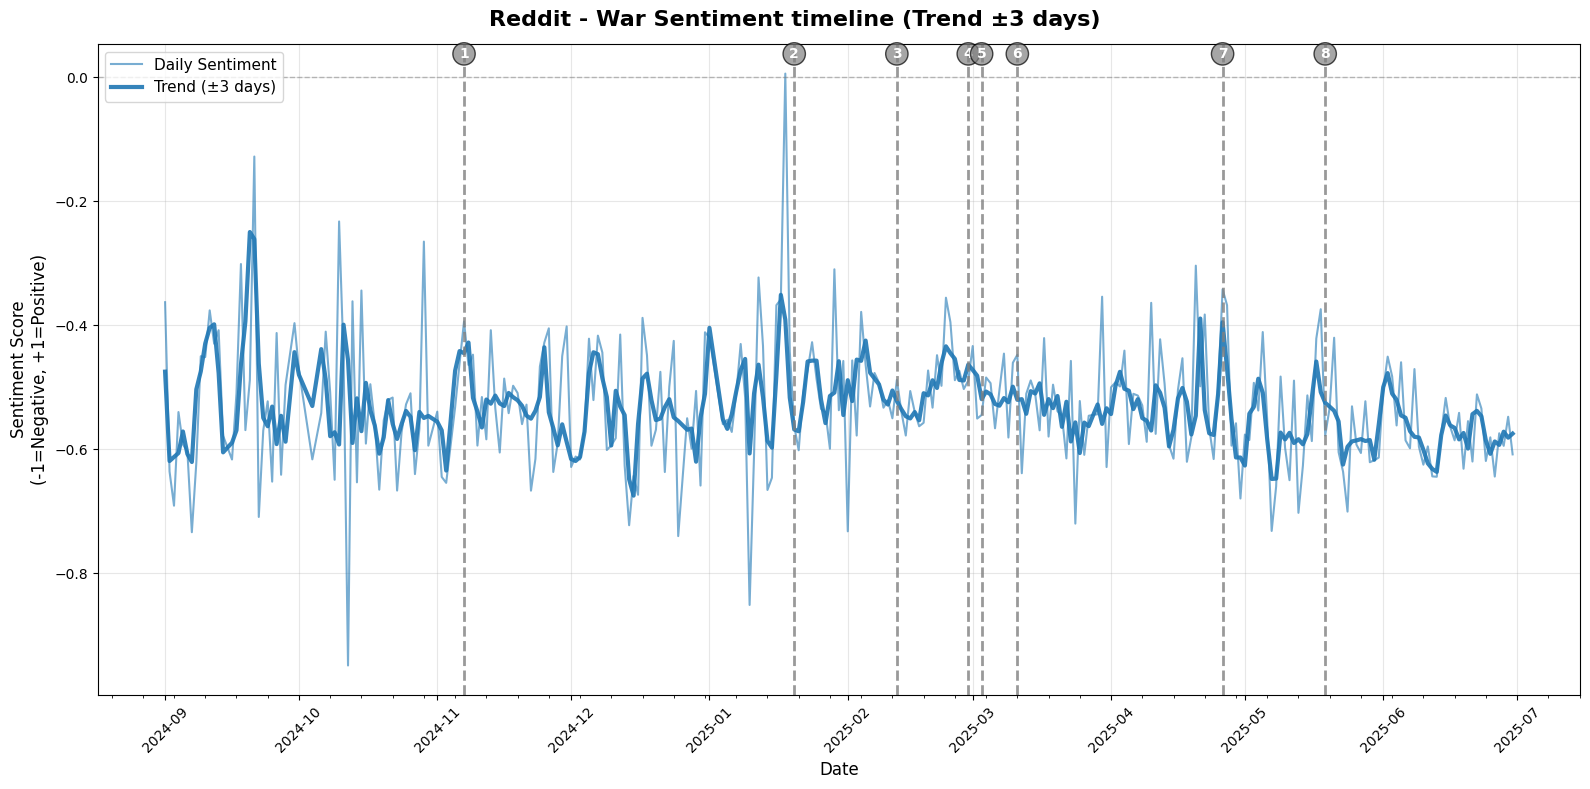


📈 EVENT IMPACT ANALYSIS - REDDIT - WAR SENTIMENT
   1) Trump elected (2024-11-07):
     Pre-event:  -0.532 (17 comments)     Post-event: -0.428 (885 comments)
     Change:     +0.104 📈 
   2) Trump inauguration (2025-01-20):
     Pre-event:  -0.331 (54 comments)     Post-event: -0.571 (519 comments)
     Change:     -0.240 📉 *
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.524 (534 comments)     Post-event: -0.535 (2116 comments)
     Change:     -0.011 📉 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.483 (1151 comments)     Post-event: -0.472 (5563 comments)
     Change:     +0.011 📈 
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.460 (4832 comments)     Post-event: -0.507 (3229 comments)
     Change:     -0.047 📉 *
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.533 (578 comments)     Post-event: -0.519 (1556 comments)
     Change:     +0.014 📈 
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
   

In [29]:
# CHART 1: REDDIT - WAR SENTIMENT
from datetime import timedelta

print("🎯 CHART 1: Reddit - War Sentiment")

if 'reddit_relevance' in locals() and not reddit_relevance.empty:
    # Prepare data
    timeline_guerra_reddit = prepare_sentiment_timeline_data(
        reddit_relevance, 
        'comment_created_utc', 
        'sentiment_numeric'
    )
    
    # Create chart
    fig1, event_list = plot_single_sentiment_timeline(
        timeline_data=timeline_guerra_reddit,
        events_dict=key_events,
        date_column='comment_created_utc',
        sentiment_name='War Sentiment',
        color='#1f77b4',
        title='Reddit - War Sentiment timeline (Trend ±3 days)',
        figsize=(16, 8)
    )

    plt.show()
    
    # Impact analysis
    impact1 = analyze_single_sentiment_impact(
        df = reddit_relevance,
        events_dict = key_events, 
        date_column = 'comment_created_utc',
        sentiment_column = "sentiment_numeric", 
        sentiment_name = 'Reddit - War Sentiment'
    )
    
else:
    print("❌ Dataset reddit_relevance not found")

Figure saved to: results/Reddit_-_War_Sentiment_timeline_(trend_±7_days).png


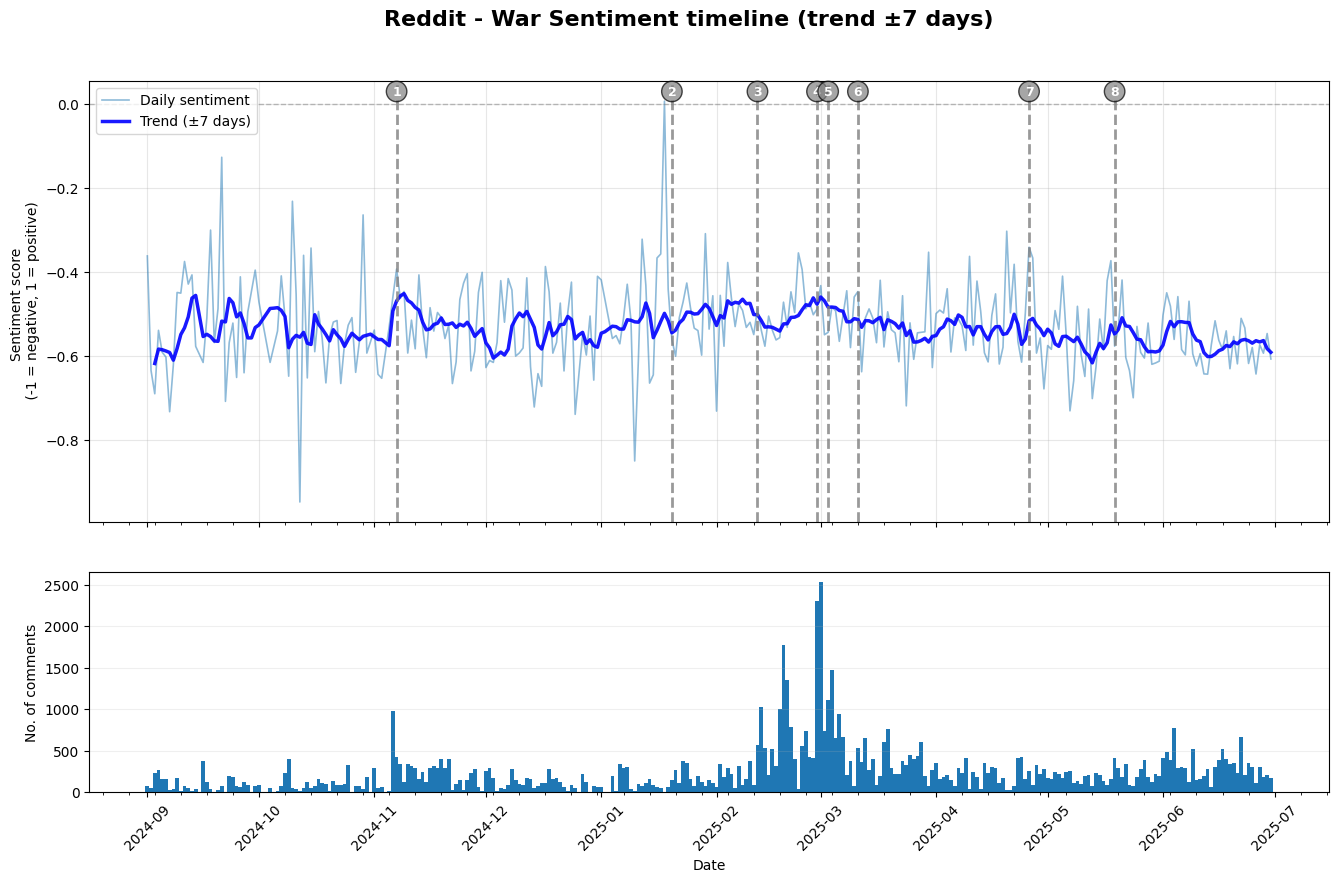


📈 EVENT IMPACT ANALYSIS - REDDIT - WAR SENTIMENT (±7 DAYS)
   1) Trump elected (2024-11-07):
     Pre-event:  -0.569 (425 comments)     Post-event: -0.492 (1985 comments)
     Change:     +0.077 📈 
   2) Trump inauguration (2025-01-20):
     Pre-event:  -0.527 (470 comments)     Post-event: -0.501 (1471 comments)
     Change:     +0.026 📈 
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.499 (1193 comments)     Post-event: -0.542 (4165 comments)
     Change:     -0.043 📉 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.457 (2934 comments)     Post-event: -0.493 (9735 comments)
     Change:     -0.036 📉 *
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.461 (6949 comments)     Post-event: -0.520 (5409 comments)
     Change:     -0.058 📉 ***
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.513 (4298 comments)     Post-event: -0.509 (2502 comments)
     Change:     +0.004 📈 
   7) Trump-Zelensky meeting (Pope funeral)

In [32]:
# === SINGLE CELL: Plot  + Impact (±7 days) with p-value ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Fallback events if missing
if 'key_events' not in globals():
    key_events = {}

# Fallback for create_event_windows if it doesn't already exist in scope
if 'create_event_windows' not in globals():
    def create_event_windows(events_dict, window_days=3):
        event_windows = {}
        for event_name, event_date in events_dict.items():
            d = pd.to_datetime(event_date)
            event_windows[event_name] = {
                'event': d,
                'before_start': d - timedelta(days=window_days),
                'before_end':   d - timedelta(days=1),
                'after_start':  d,
                'after_end':    d + timedelta(days=window_days)
            }
        return event_windows

# --- compute simple and weighted 7-day trends (time-based rolling) ---
def _add_trends_7d_compare(timeline_data, date_column):
    td = timeline_data.copy().sort_values(date_column)
    td = td.dropna(subset=['sentiment_mean'])
    td = td.set_index(date_column)  # required for time-based rolling "7D"

    # Weighted trend: weights = comment_count
    num = (td['sentiment_mean'] * td['comment_count']).rolling('7D', min_periods=3).sum()
    den = td['comment_count'].rolling('7D', min_periods=3).sum()
    td['trend_7d_weighted'] = num / den

    return td.reset_index()

# --- full plot: two panels + events ---
def plot_trends_compare_with_volume_and_events(
    timeline_data,
    events_dict,
    date_column='comment_created_utc',
    title='Reddit - 7D Trend Comparison (simple vs weighted)',
    min_comments_for_line=5,
    figsize=(16, 9)
):
    td = _add_trends_7d_compare(timeline_data, date_column).sort_values(date_column)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.15)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Daily line only for "robust" days
    daily_line = td[td['comment_count'] >= min_comments_for_line]
    if not daily_line.empty:
        ax1.plot(daily_line[date_column], daily_line['sentiment_mean'],
                 linewidth=1.2, alpha=0.5, label=f"Daily sentiment")

    if td['trend_7d_weighted'].notna().any():
        ax1.plot(td[date_column], td['trend_7d_weighted'],
                 linewidth=2.5, alpha=0.9, label='Trend (±7 days)', color='blue')

    ax1.axhline(0, linestyle='--', color='gray', alpha=0.5, linewidth=1)
    ax1.set_ylabel('Sentiment score \n (-1 = negative, 1 = positive)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Numbered events
    event_list = []
    ev_win = create_event_windows(events_dict, window_days=3) if events_dict else {}
    for i, (name, win) in enumerate(ev_win.items(), 1):
        ax1.axvline(win['event'], color='grey', linestyle='--', linewidth=2, alpha=0.8)
        ymax = ax1.get_ylim()[1]
        ax1.annotate(str(i),
                     xy=(win['event'], ymax),
                     xytext=(0, -10), textcoords='offset points',
                     bbox=dict(boxstyle='circle,pad=0.3', fc='grey', alpha=0.7),
                     fontsize=9, ha='center', fontweight='bold', color='white')
        event_list.append(f"{i} = {name}")

    # X axis (dates)
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())

    # Volume histogram (bottom)
    ax2.bar(td[date_column], td['comment_count'], width=1.0)
    ax2.set_ylabel('No. of comments')
    ax2.set_xlabel('Date')
    ax2.grid(True, axis='y', alpha=0.2)

    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    out_path = f"results/{title.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')

    return fig, (event_list, out_path)

# === RUN ===
# 1) Prepare the timeline if it doesn't exist
if 'timeline_guerra_reddit' not in globals():
    if 'reddit_relevance' in globals() and not reddit_relevance.empty:
        timeline_guerra_reddit = prepare_sentiment_timeline_data(
            reddit_relevance, 'comment_created_utc', 'sentiment_numeric'
        )
    else:
        raise RuntimeError("Both 'timeline_guerra_reddit' and 'reddit_relevance' are missing.")

# 2) Plot
fig, (event_list, img_path) = plot_trends_compare_with_volume_and_events(
    timeline_data=timeline_guerra_reddit,
    events_dict=key_events,
    date_column='comment_created_utc',
    title='Reddit - War Sentiment timeline (trend ±7 days)',
    min_comments_for_line=3,
    figsize=(16, 9)
)

print("Figure saved to:", img_path)
plt.show()

# 3) Simple impact on actual comments (±7 days) — with p-value
impact1_7d = analyze_single_sentiment_impact(
    df=reddit_relevance,
    events_dict=key_events,
    date_column='comment_created_utc',
    sentiment_column='sentiment_numeric',
    sentiment_name='Reddit - War Sentiment (±7 days)',
    window_days=7
)

# Compact table with p-value
if isinstance(impact1_7d, dict) and impact1_7d:
    impact_df = (pd.DataFrame.from_dict(impact1_7d, orient='index')
                   .reset_index().rename(columns={'index':'event'}))
    cols = ["event","pre","post","change","pre_count","post_count","p_value","significance"]
    impact_df = impact_df[cols]
    print("\n🧪 Event impact (±7 days) on sentiment_numeric:")
    print(impact_df.round({"pre":3,"post":3,"change":3,"p_value":4}).to_string(index=False))
else:
    print("\nNo impact results available (insufficient data in the windows).")


CHART 2: Reddit - Sentiment towards Trump
     ✓ 150 days with data


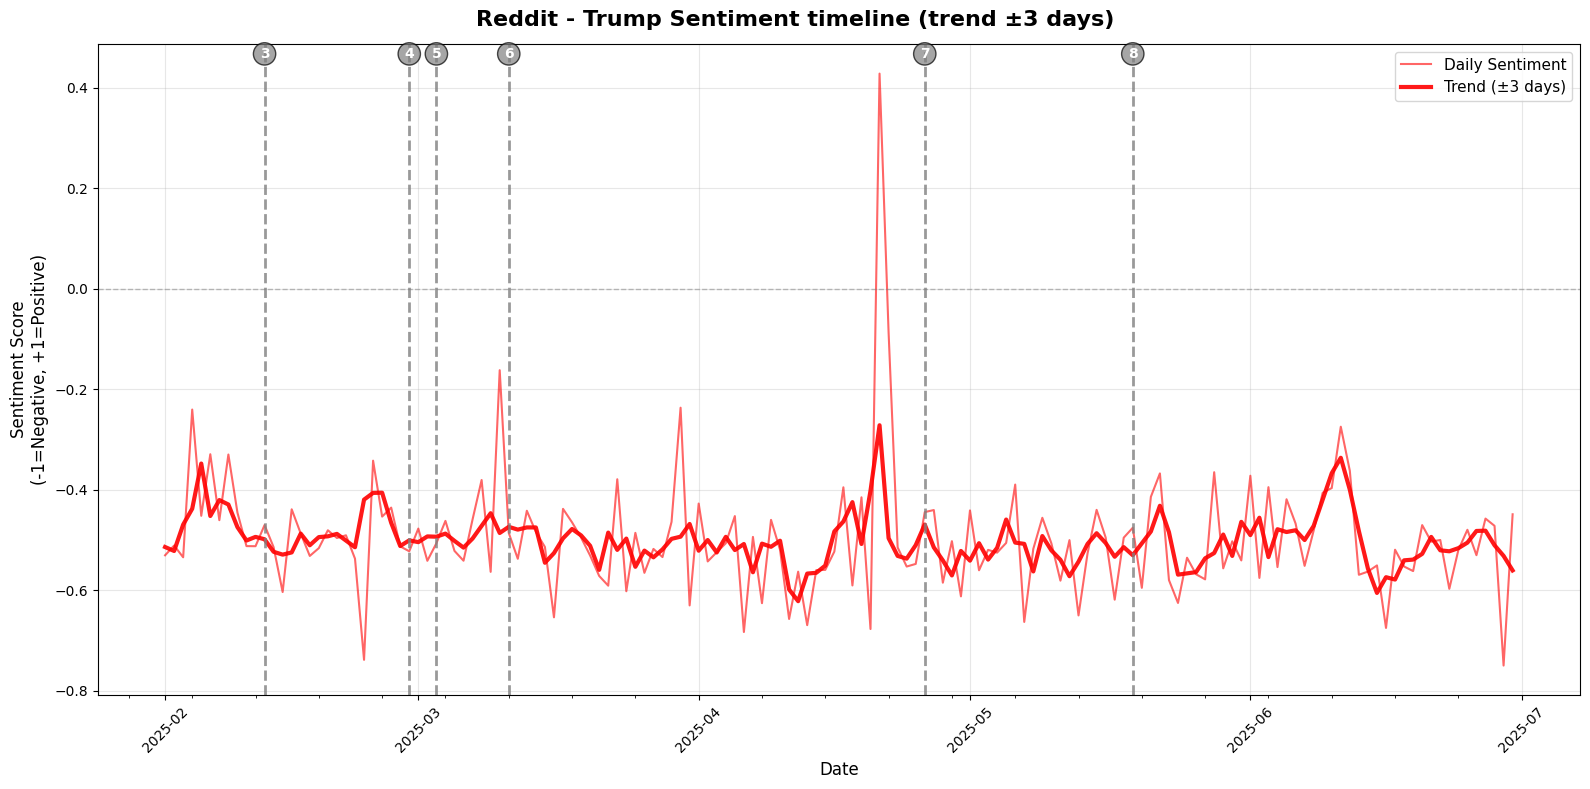


📈 EVENT IMPACT ANALYSIS - REDDIT - TRUMP SENTIMENT
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.500 (395 comments)     Post-event: -0.524 (994 comments)
     Change:     -0.023 📉 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.448 (692 comments)     Post-event: -0.505 (3818 comments)
     Change:     -0.057 📉 
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.500 (3399 comments)     Post-event: -0.488 (1654 comments)
     Change:     +0.012 📈 
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.486 (322 comments)     Post-event: -0.480 (813 comments)
     Change:     +0.006 📈 
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
     Pre-event:  -0.535 (519 comments)     Post-event: -0.515 (614 comments)
     Change:     +0.020 📈 
   8) Second Trump-Putin call (2025-05-19):
     Pre-event:  -0.550 (213 comments)     Post-event: -0.507 (582 comments)
     Change:     +0.043 📈 


In [39]:
# CHART 2: REDDIT - TRUMP SENTIMENT
print("CHART 2: Reddit - Sentiment towards Trump")

if 'reddit_relevance_cut' in locals() and not reddit_relevance_cut.empty:
    # Prepare data
    timeline_trump_reddit = prepare_sentiment_timeline_data(
        reddit_relevance_cut, 
        'comment_created_utc', 
        'trump_sentiment'
    )
    
    # Create chart
    fig2, event_list = plot_single_sentiment_timeline(
        timeline_data=timeline_trump_reddit,
        events_dict=key_events2,
        date_column='comment_created_utc',
        sentiment_name='Trump Sentiment',
        color='red',
        title='Reddit - Trump Sentiment timeline (trend ±3 days)',
        figsize=(16, 8)
    )

    plt.show()
    
    # Impact analysis
    impact2 = analyze_single_sentiment_impact(
        df=reddit_relevance_cut,
        events_dict=key_events2, 
        date_column='comment_created_utc',
        sentiment_column='trump_sentiment',
        sentiment_name='Reddit - Trump Sentiment'
    )
    
else:
    print("❌ Dataset reddit_relevance_cut not found")


Figure saved to: results/Reddit_-_Trump_Sentiment_timeline_(trend_±7_days).png


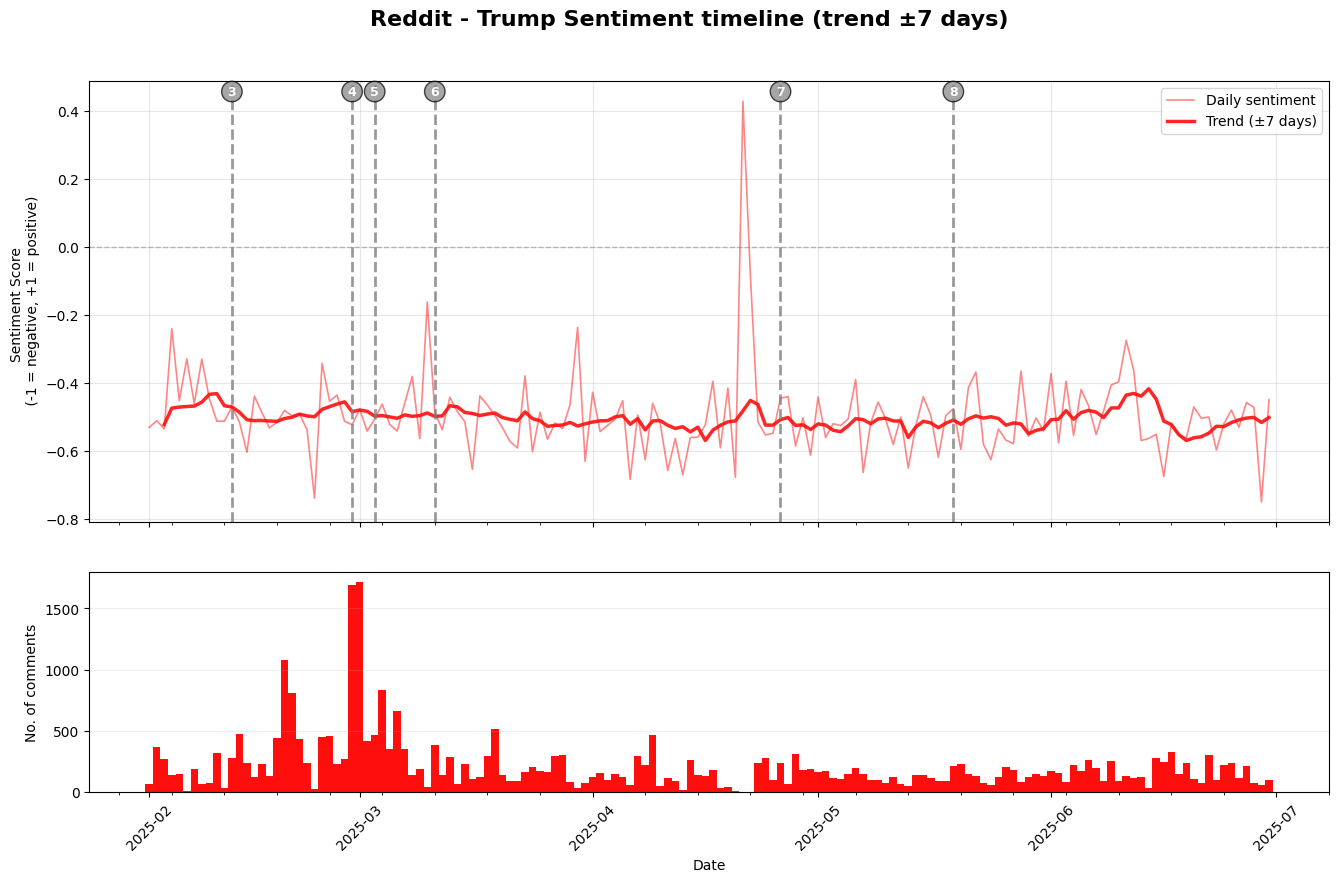


📈 EVENT IMPACT ANALYSIS - REDDIT - TRUMP SENTIMENT (±7 DAYS)
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.465 (814 comments)     Post-event: -0.513 (1919 comments)
     Change:     -0.048 📉 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.447 (1837 comments)     Post-event: -0.504 (6134 comments)
     Change:     -0.057 📉 **
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.478 (4813 comments)     Post-event: -0.496 (2986 comments)
     Change:     -0.018 📉 
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.494 (2516 comments)     Post-event: -0.496 (1341 comments)
     Change:     -0.002 📉 
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
     Pre-event:  -0.520 (576 comments)     Post-event: -0.524 (1316 comments)
     Change:     -0.004 📉 
   8) Second Trump-Putin call (2025-05-19):
     Pre-event:  -0.522 (610 comments)     Post-event: -0.504 (971 comments)
     Change:     +0.017 📈 

🧪 Event impact 

In [41]:
# === Reddit - Trump Sentiment ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Fallback events if missing
if 'key_events' not in globals():
    key_events = {}

# Fallback for create_event_windows if it doesn't exist yet
if 'create_event_windows' not in globals():
    def create_event_windows(events_dict, window_days=3):
        event_windows = {}
        for event_name, event_date in events_dict.items():
            d = pd.to_datetime(event_date)
            event_windows[event_name] = {
                'event': d,
                'before_start': d - timedelta(days=window_days),
                'before_end':   d - timedelta(days=1),
                'after_start':  d,
                'after_end':    d + timedelta(days=window_days)
            }
        return event_windows

# --- compute simple and weighted 7-day trends (time-based rolling) ---
def _add_trends_7d_compare(timeline_data, date_column):
    td = timeline_data.copy().sort_values(date_column)
    td = td.dropna(subset=['sentiment_mean'])
    td = td.set_index(date_column)  # required for "7D" time-based rolling

    # Weighted trend: weights = comment_count
    num = (td['sentiment_mean'] * td['comment_count']).rolling('7D', min_periods=3).sum()
    den = td['comment_count'].rolling('7D', min_periods=3).sum()
    td['trend_7d_weighted'] = num / den

    return td.reset_index()

# --- full plot: two panels + events ---
def plot_trump_trends_with_volume(
    timeline_data,
    events_dict,
    date_column='comment_created_utc',
    title='Reddit - Trump Sentiment timeline (trend ±7 days)',
    color='red',
    min_comments_for_line=3,
    figsize=(16, 9)
):
    td = _add_trends_7d_compare(timeline_data, date_column).sort_values(date_column)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.15)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Daily line only for "robust" days
    daily_line = td[td['comment_count'] >= min_comments_for_line]
    if not daily_line.empty:
        ax1.plot(daily_line[date_column], daily_line['sentiment_mean'],
                 linewidth=1.2, alpha=0.5, label=f"Daily sentiment", color=color)

    if td['trend_7d_weighted'].notna().any():
        ax1.plot(td[date_column], td['trend_7d_weighted'],
                 linewidth=2.5, alpha=0.9, label='Trend (±7 days)', color=color)

    ax1.axhline(0, linestyle='--', color='gray', alpha=0.5, linewidth=1)
    ax1.set_ylabel('Sentiment Score \n (-1 = negative, +1 = positive)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # Numbered events
    event_list = []
    ev_win = create_event_windows(events_dict, window_days=3) if events_dict else {}
    for i, (name, win) in enumerate(ev_win.items(), 1):
        ax1.axvline(win['event'], color='grey', linestyle='--', linewidth=2, alpha=0.8)
        ymax = ax1.get_ylim()[1]
        ax1.annotate(str(name[0]),
                     xy=(win['event'], ymax),
                     xytext=(0, -10), textcoords='offset points',
                     bbox=dict(boxstyle='circle,pad=0.3', fc='grey', alpha=0.7),
                     fontsize=9, ha='center', fontweight='bold', color='white')
        event_list.append(f"{i} = {name}")

    # X axis (dates)
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())

    # Volume histogram
    ax2.bar(td[date_column], td['comment_count'], width=1.0, color = "#ff0e0e")
    ax2.set_ylabel('No. of comments')
    ax2.set_xlabel('Date')
    ax2.grid(True, axis='y', alpha=0.2)

    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    out_path = f"results/{title.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')

    return fig, (event_list, out_path)

# === RUN ===
# 1) Prepare timeline on trump_sentiment (uses your function)
if 'timeline_trump_reddit' not in globals():
    if 'reddit_relevance_cut' in globals() and not reddit_relevance_cut.empty:
        timeline_trump_reddit = prepare_sentiment_timeline_data(
            reddit_relevance_cut, 'comment_created_utc', 'trump_sentiment'
        )
    else:
        raise RuntimeError("Missing 'reddit_relevance_cut' or it is empty.")

# 2) Plot
fig2, (event_list, img_path) = plot_trump_trends_with_volume(
    timeline_data=timeline_trump_reddit,
    events_dict=key_events2,
    date_column='comment_created_utc',
    title='Reddit - Trump Sentiment timeline (trend ±7 days)',
    color="#ff0e0e",
    min_comments_for_line=3,
    figsize=(16, 9)
)

# print("\nEvents used:")
# print(*event_list, sep="\n")
print("Figure saved to:", img_path)
plt.show()

# 3) Simple impact analysis on actual comments (±7 days) — includes p-value
impact_trump_7d = analyze_single_sentiment_impact(
    df=reddit_relevance,
    events_dict=key_events2,
    date_column='comment_created_utc',
    sentiment_column='trump_sentiment',
    sentiment_name='Reddit - Trump Sentiment (±7 days)',
    window_days=7
)

# Compact table with p-value
if isinstance(impact_trump_7d, dict) and impact_trump_7d:
    impact_df = (pd.DataFrame.from_dict(impact_trump_7d, orient='index')
                    .reset_index().rename(columns={'index':'event'}))
    cols = ["event","pre","post","change","pre_count","post_count","p_value","significance"]
    impact_df = impact_df[cols]
    print("\n🧪 Event impact (±7 days) on trump_sentiment:")
    print(impact_df.round({"pre":3,"post":3,"change":3,"p_value":4}).to_string(index=False))
else:
    print("\nNo impact results available (insufficient data in the windows).")

     ✓ 139 days with data


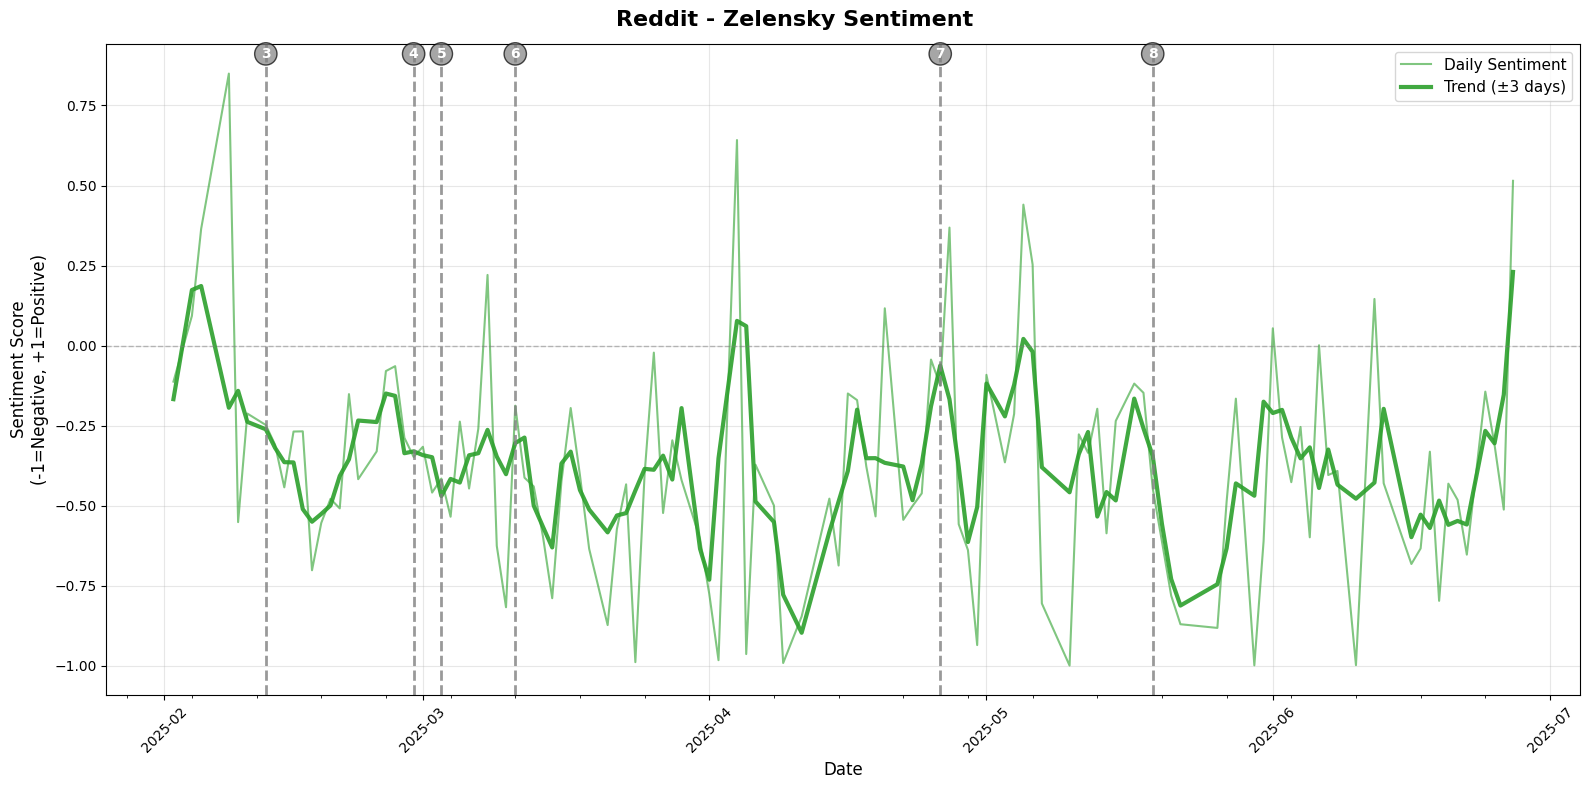


📈 EVENT IMPACT ANALYSIS - REDDIT - ZELENSKY SENTIMENT TIMELINE (±3 DAYS)
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.306 (18 comments)     Post-event: -0.319 (166 comments)
     Change:     -0.013 📉 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.074 (84 comments)     Post-event: -0.342 (1966 comments)
     Change:     -0.268 📉 **
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.331 (1803 comments)     Post-event: -0.416 (480 comments)
     Change:     -0.085 📉 
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.267 (59 comments)     Post-event: -0.287 (93 comments)
     Change:     -0.020 📉 
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
     Pre-event:  -0.479 (53 comments)     Post-event: -0.167 (116 comments)
     Change:     +0.312 📈 *
   8) Second Trump-Putin call (2025-05-19):
     Pre-event:  -0.236 (9 comments)     Post-event: -0.557 (51 comments)
     Change:     -0.321 📉 


In [43]:
# CHART 3: REDDIT - ZELENSKY SENTIMENT
if 'reddit_relevance_cut' in locals() and not reddit_relevance_cut.empty:
    # Prepare data
    timeline_zelensky_reddit = prepare_sentiment_timeline_data(
        reddit_relevance_cut, 
        'comment_created_utc', 
        'zelensky_sentiment'
    )
    
    # Create chart
    fig3, event_list = plot_single_sentiment_timeline(
        timeline_data=timeline_zelensky_reddit,
        events_dict=key_events2,
        date_column='comment_created_utc',
        sentiment_name='Zelensky Sentiment',
        color='#2ca02c',
        title='Reddit - Zelensky Sentiment',
        figsize=(16, 8)
    )
    
    plt.show()
    
    # Impact analysis
    impact3 = analyze_single_sentiment_impact(
        df=reddit_relevance_cut,
        events_dict=key_events2, 
        date_column='comment_created_utc',
        sentiment_column='zelensky_sentiment',
        sentiment_name='Reddit - Zelensky Sentiment timeline (±3 days)'
    )

else:
    print("❌ Dataset reddit_relevance_cut not found")


Figure saved to: results/Reddit_-_Zelensky_Sentiment_timeline_(±7_days).png


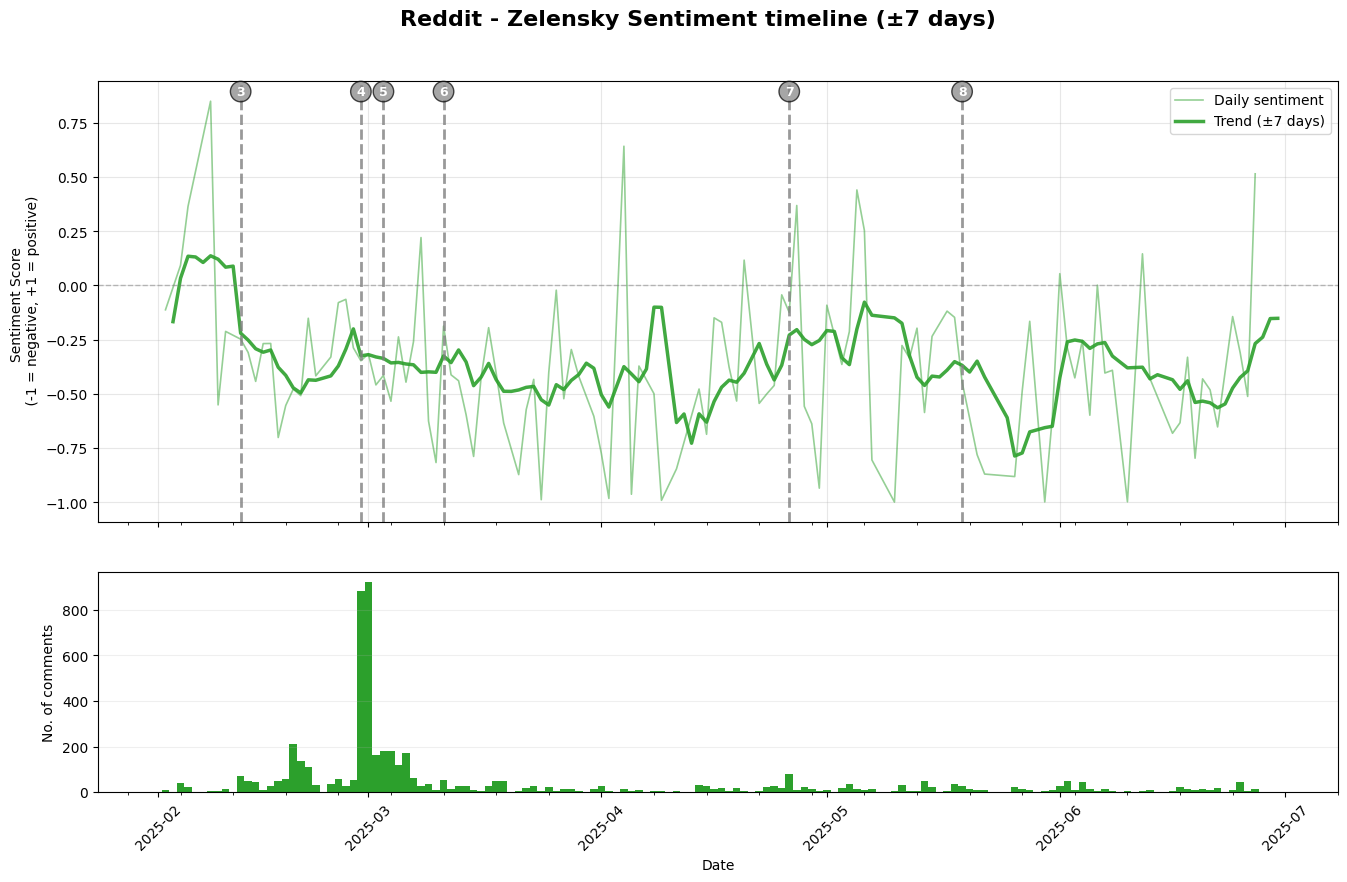


📈 EVENT IMPACT ANALYSIS - REDDIT - ZELENSKY SENTIMENT TIMELINE (±7 DAYS)
   3) Trump calls Putin (2025-02-12):
     Pre-event:  +0.077 (48 comments)     Post-event: -0.415 (306 comments)
     Change:     -0.492 📉 ***
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.183 (263 comments)     Post-event: -0.362 (2616 comments)
     Change:     -0.179 📉 **
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.319 (1975 comments)     Post-event: -0.399 (772 comments)
     Change:     -0.079 📉 *
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.394 (591 comments)     Post-event: -0.360 (163 comments)
     Change:     +0.034 📈 
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
     Pre-event:  -0.441 (80 comments)     Post-event: -0.212 (144 comments)
     Change:     +0.229 📈 
   8) Second Trump-Putin call (2025-05-19):
     Pre-event:  -0.431 (90 comments)     Post-event: -0.610 (63 comments)
     Change:     -0.179 📉 

🧪 Event i

In [48]:
# === SINGLE CELL: Reddit - Zelensky Sentiment (7D trend plot + ±7 impact with p-value) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Fallback events if missing
if 'key_events' not in globals():
    key_events = {}

# Fallback for create_event_windows if it doesn't already exist
if 'create_event_windows' not in globals():
    def create_event_windows(events_dict, window_days=3):
        event_windows = {}
        for event_name, event_date in events_dict.items():
            d = pd.to_datetime(event_date)
            event_windows[event_name] = {
                'event': d,
                'before_start': d - timedelta(days=window_days),
                'before_end':   d - timedelta(days=1),
                'after_start':  d,
                'after_end':    d + timedelta(days=window_days)
            }
        return event_windows

# --- compute simple and weighted 7-day trends (time-based rolling) ---
def _add_trends_7d_compare(timeline_data, date_column):
    td = timeline_data.copy().sort_values(date_column)
    td = td.dropna(subset=['sentiment_mean'])
    td = td.set_index(date_column)  # required for "7D" rolling

    # Weighted trend: weights = comment_count
    num = (td['sentiment_mean'] * td['comment_count']).rolling('7D', min_periods=3).sum()
    den = td['comment_count'].rolling('7D', min_periods=3).sum()
    td['trend_7d_weighted'] = num / den

    return td.reset_index()

# --- full plot: two panels + events ---
def plot_zelensky_trends_with_volume(
    timeline_data,
    events_dict,
    date_column='comment_created_utc',
    title='Reddit - Sentiment towards Zelensky (7D Trend: simple vs weighted)',
    color='#2ca02c',
    min_comments_for_line=3,
    figsize=(16, 9)
):
    td = _add_trends_7d_compare(timeline_data, date_column).sort_values(date_column)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.15)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Daily line only for "robust" days
    daily_line = td[td['comment_count'] >= min_comments_for_line]
    if not daily_line.empty:
        ax1.plot(daily_line[date_column], daily_line['sentiment_mean'],
                 linewidth=1.2, alpha=0.5, label=f"Daily sentiment", color=color)

    if td['trend_7d_weighted'].notna().any():
        ax1.plot(td[date_column], td['trend_7d_weighted'],
                 linewidth=2.5, alpha=0.9, label='Trend (±7 days)', color=color)

    ax1.axhline(0, linestyle='--', color='gray', alpha=0.5, linewidth=1)
    ax1.set_ylabel('Sentiment Score \n (-1 = negative, +1 = positive)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # Numbered events
    event_list = []
    ev_win = create_event_windows(events_dict, window_days=3) if events_dict else {}
    for i, (name, win) in enumerate(ev_win.items(), 1):
        ax1.axvline(win['event'], color='grey', linestyle='--', linewidth=2, alpha=0.8)
        ymax = ax1.get_ylim()[1]
        ax1.annotate(str(name[0]),
                     xy=(win['event'], ymax),
                     xytext=(0, -10), textcoords='offset points',
                     bbox=dict(boxstyle='circle,pad=0.3', fc='grey', alpha=0.7),
                     fontsize=9, ha='center', fontweight='bold', color='white')
        event_list.append(f"{i} = {name}")

    # X axis (dates)
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())

    # Volume histogram
    ax2.bar(td[date_column], td['comment_count'], width=1.0, color = '#2ca02c')
    ax2.set_ylabel('No. of comments')
    ax2.set_xlabel('Date')
    ax2.grid(True, axis='y', alpha=0.2)

    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    out_path = f"results/{title.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')

    return fig, (event_list, out_path)

# === RUN ===
# 1) Prepare timeline on zelensky_sentiment
if 'timeline_zelensky_reddit' not in globals():
    if 'reddit_relevance_cut' in globals() and not reddit_relevance_cut.empty:
        timeline_zelensky_reddit = prepare_sentiment_timeline_data(
            reddit_relevance_cut, 'comment_created_utc', 'zelensky_sentiment'
        )
    else:
        raise RuntimeError("Missing 'reddit_relevance_cut' or it is empty.")

# 2) Plot
fig3, (event_list, img_path) = plot_zelensky_trends_with_volume(
    timeline_data=timeline_zelensky_reddit,
    events_dict=key_events2,
    date_column='comment_created_utc',
    title='Reddit - Zelensky Sentiment timeline (±7 days)',
    color='#2ca02c',
    min_comments_for_line=3,
    figsize=(16, 9)
)

print("Figure saved to:", img_path)
plt.show()

# 3) Simple impact analysis on actual comments (±7 days) — includes p-value
impact_zelensky_7d = analyze_single_sentiment_impact(
    df=reddit_relevance_cut,
    events_dict=key_events2,
    date_column='comment_created_utc',
    sentiment_column='zelensky_sentiment',
    sentiment_name='Reddit - Zelensky Sentiment timeline (±7 days)',
    window_days=7
)

# Compact table with p-value
if isinstance(impact_zelensky_7d, dict) and impact_zelensky_7d:
    impact_df = (pd.DataFrame.from_dict(impact_zelensky_7d, orient='index')
                    .reset_index().rename(columns={'index':'event'}))
    cols = ["event","pre","post","change","pre_count","post_count","p_value","significance"]
    impact_df = impact_df[cols]
    print("\n🧪 Event impact (±7 days) on zelensky_sentiment:")
    print(impact_df.round({"pre":3,"post":3,"change":3,"p_value":4}).to_string(index=False))
else:
    print("\nNo impact results available (insufficient data in the windows).")


In [64]:
# # GRAFICO 4: REDDIT - SENTIMENT PEACE

# print("🕊️ GRAFICO 4: Reddit - Sentiment verso la Pace")

# if 'reddit_relevance_cut' in locals() and not reddit_relevance_cut.empty:
#     # Prepara dati
#     timeline_peace_reddit = prepare_sentiment_timeline_data(
#         reddit_relevance_cut, 
#         'comment_created_utc', 
#         'peace_sentiment'
#     )
    
#     # Crea grafico
#     fig4, event_list = plot_single_sentiment_timeline(
#         timeline_data=timeline_peace_reddit,
#         events_dict=key_events2,
#         date_column='comment_created_utc',
#         sentiment_name='Sentiment Peace',
#         color='#d62728',
#         title='Reddit - Sentiment verso la Pace',
#         figsize=(16, 8)
#     )
    
#     plt.show()
    
#     # Analisi impatto
#     impact4 = analyze_single_sentiment_impact(
#         df=reddit_relevance_cut,
#         events_dict=key_events2, 
#         date_column='comment_created_utc',
#         sentiment_column='peace_sentiment',
#         sentiment_name='Reddit - Sentiment Pace'
#     )

# else:
#     print("❌ Dataset reddit_relevance_cut non trovato")

In [67]:
# ## AGGIUNTA ELISA
# # === UNICA CELLA: Reddit - Sentiment Pace (plot trend 7D + impatto ±7 con p-value) ===
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# from datetime import timedelta

# print("🕊️ GRAFICO 4: Reddit - Sentiment verso la Pace")

# # Fallback eventi se mancano
# if 'key_events' not in globals():
#     key_events = {}

# # Fallback per create_event_windows se non esiste già
# if 'create_event_windows' not in globals():
#     def create_event_windows(events_dict, window_days=3):
#         event_windows = {}
#         for event_name, event_date in events_dict.items():
#             d = pd.to_datetime(event_date)
#             event_windows[event_name] = {
#                 'event': d,
#                 'before_start': d - timedelta(days=window_days),
#                 'before_end':   d - timedelta(days=1),
#                 'after_start':  d,
#                 'after_end':    d + timedelta(days=window_days)
#             }
#         return event_windows

# # --- calcolo trend semplice e pesato su 7 giorni (rolling time-based) ---
# def _add_trends_7d_compare(timeline_data, date_column):
#     td = timeline_data.copy().sort_values(date_column)
#     td = td.dropna(subset=['sentiment_mean'])
#     td = td.set_index(date_column)  # necessario per rolling "7D"

#     # Trend semplice: media aritmetica delle medie giornaliere
#     td['trend_7d_simple'] = td['sentiment_mean'].rolling('7D', min_periods=3).mean()

#     # Trend pesato: pesi = comment_count
#     num = (td['sentiment_mean'] * td['comment_count']).rolling('7D', min_periods=3).sum()
#     den = td['comment_count'].rolling('7D', min_periods=3).sum()
#     td['trend_7d_weighted'] = num / den

#     return td.reset_index()

# # --- plot completo: due pannelli + eventi ---
# def plot_peace_trends_with_volume(
#     timeline_data,
#     events_dict,
#     date_column='comment_created_utc',
#     title='Reddit - Sentiment verso la Pace (Trend 7D: semplice vs pesato)',
#     color='#d62728',
#     min_comments_for_line=3,
#     figsize=(16, 9)
# ):
#     td = _add_trends_7d_compare(timeline_data, date_column).sort_values(date_column)

#     fig = plt.figure(figsize=figsize)
#     gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.15)
#     ax1 = fig.add_subplot(gs[0, 0])
#     ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
#     fig.suptitle(title, fontsize=16, fontweight='bold')

#     # Linea giornaliera solo per giorni "robusti"
#     daily_line = td[td['comment_count'] >= min_comments_for_line]
#     if not daily_line.empty:
#         ax1.plot(daily_line[date_column], daily_line['sentiment_mean'],
#                  linewidth=1.2, alpha=0.5, label=f"Sentiment giornaliero (≥{min_comments_for_line})", color=color)

#     # Trend 7D semplice e pesato
#     # if td['trend_7d_simple'].notna().any():
#     #     ax1.plot(td[date_column], td['trend_7d_simple'],
#     #              linewidth=2, alpha=0.8, label='Trend 7 giorni (semplice)', color='orange')
#     if td['trend_7d_weighted'].notna().any():
#         ax1.plot(td[date_column], td['trend_7d_weighted'],
#                  linewidth=2.5, alpha=0.9, label='Trend 7 giorni (pesato)', color=color)

#     ax1.axhline(0, linestyle='--', color='gray', alpha=0.5, linewidth=1)
#     ax1.set_ylabel('Sentiment (-1, +1)')
#     ax1.grid(True, alpha=0.3)
#     ax1.legend(loc='upper left')

#     # Eventi numerati
#     event_list = []
#     ev_win = create_event_windows(events_dict, window_days=3) if events_dict else {}
#     for i, (name, win) in enumerate(ev_win.items(), 1):
#         ax1.axvline(win['event'], color='grey', linestyle='--', linewidth=2, alpha=0.8)
#         ymax = ax1.get_ylim()[1]
#         ax1.annotate(str(name[1]),
#                      xy=(win['event'], ymax),
#                      xytext=(0, -10), textcoords='offset points',
#                      bbox=dict(boxstyle='circle,pad=0.3', fc='grey', alpha=0.7),
#                      fontsize=9, ha='center', fontweight='bold', color='white')
#         event_list.append(f"{i} = {name}")

#     # Asse X (date)
#     ax1.xaxis.set_major_locator(mdates.MonthLocator())
#     ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
#     ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())

#     # Istogramma volumi
#     ax2.bar(td[date_column], td['comment_count'], width=1.0)
#     ax2.set_ylabel('N. commenti')
#     ax2.set_xlabel('Data')
#     ax2.grid(True, axis='y', alpha=0.2)

#     plt.setp(ax1.get_xticklabels(), visible=False)
#     plt.setp(ax2.get_xticklabels(), rotation=45)

#     plt.tight_layout()
#     plt.subplots_adjust(top=0.90)

#     out_path = f"results/{title.replace(' ', '_')}.png"
#     plt.savefig(out_path, dpi=150, bbox_inches='tight')

#     return fig, (event_list, out_path)

# # === ESECUZIONE ===
# if 'timeline_peace_reddit' not in globals():
#     if 'reddit_relevance_cut' in globals() and not reddit_relevance_cut.empty:
#         timeline_peace_reddit = prepare_sentiment_timeline_data(
#             reddit_relevance_cut, 'comment_created_utc', 'peace_sentiment'
#         )
#     else:
#         raise RuntimeError("Manca 'reddit_relevance_cut' o è vuoto.")

# fig4, (event_list, img_path) = plot_peace_trends_with_volume(
#     timeline_data=timeline_peace_reddit,
#     events_dict=key_events2,
#     date_column='comment_created_utc',
#     title='Reddit - Sentiment verso la Pace (Trend 7D: semplice vs pesato)',
#     color='#d62728',
#     min_comments_for_line=3,
#     figsize=(16, 9)
# )

# print("Figura salvata in:", img_path)
# plt.show()

# # Analisi impatto semplice (±7 giorni) — p-value incluso
# impact_peace_7d = analyze_single_sentiment_impact(
#     df=reddit_relevance_cut,
#     events_dict=key_events2,
#     date_column='comment_created_utc',
#     sentiment_column='peace_sentiment',
#     sentiment_name='Reddit - Sentiment Pace (±7 giorni)',
#     window_days=7
# )

# # Tabellina compatta con p-value
# if isinstance(impact_peace_7d, dict) and impact_peace_7d:
#     impact_df = (pd.DataFrame.from_dict(impact_peace_7d, orient='index')
#                     .reset_index().rename(columns={'index':'event'}))
#     cols = ["event","pre","post","change","pre_count","post_count","p_value","significance"]
#     impact_df = impact_df[cols]
#     print("\n🧪 Impatto eventi (±7 giorni) su peace_sentiment:")
#     print(impact_df.round({"pre":3,"post":3,"change":3,"p_value":4}).to_string(index=False))
# else:
#     print("\nNessun risultato di impatto disponibile (dati insufficienti nelle finestre).")


🎯 CHART 5: YouTube - War Sentiment
     ✓ 300 days with data


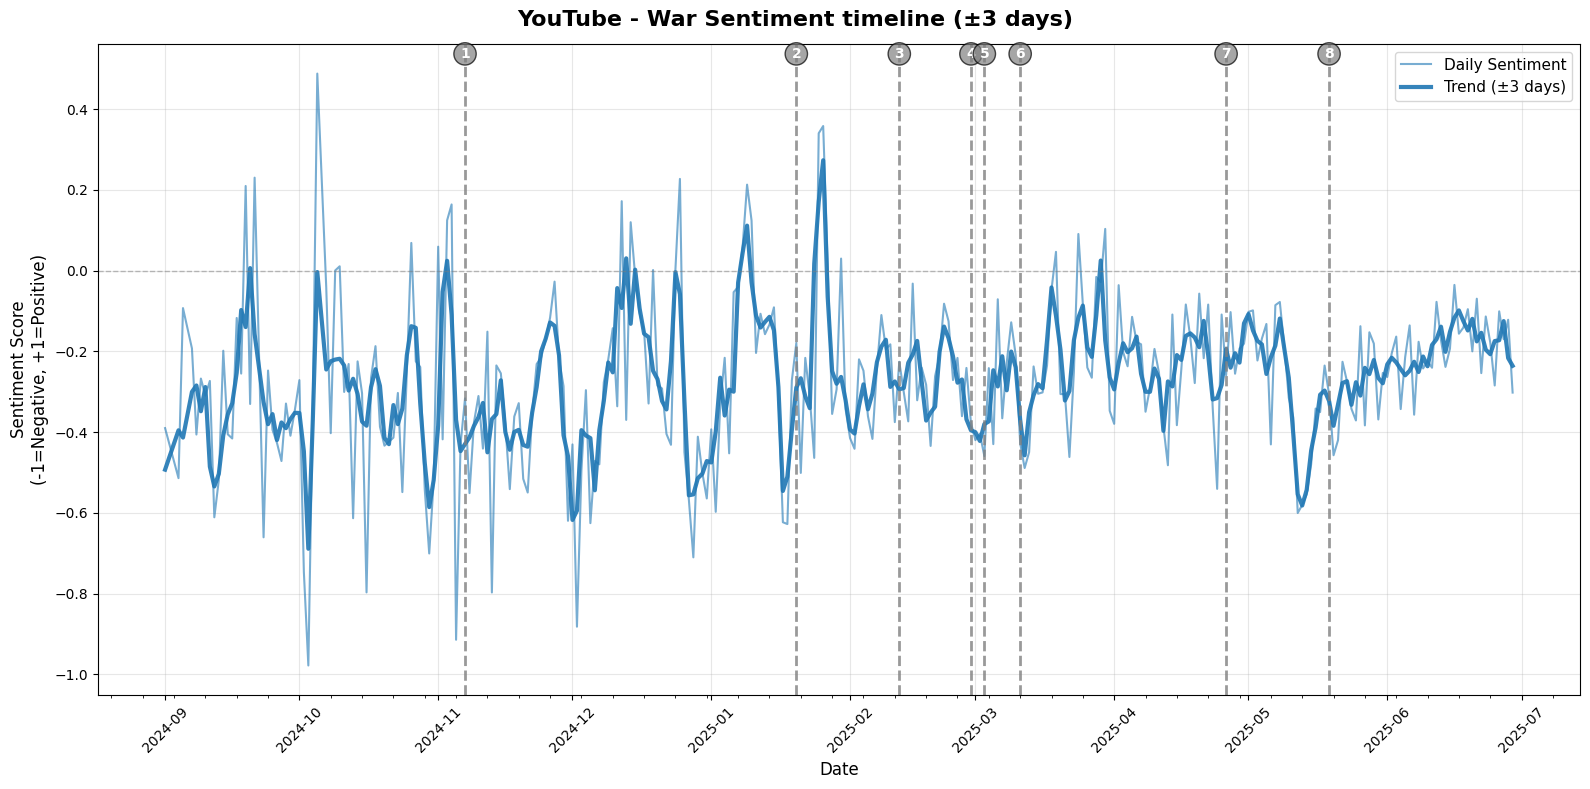


📈 EVENT IMPACT ANALYSIS - YOUTUBE - WAR SENTIMENT
   1) Trump elected (2024-11-07):
     Pre-event:  -0.211 (23 comments)     Post-event: -0.413 (56 comments)
     Change:     -0.202 📉 
   2) Trump inauguration (2025-01-20):
     Pre-event:  -0.626 (95 comments)     Post-event: -0.266 (86 comments)
     Change:     +0.359 📈 **
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.189 (321 comments)     Post-event: -0.291 (1396 comments)
     Change:     -0.101 📉 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.282 (961 comments)     Post-event: -0.400 (16498 comments)
     Change:     -0.118 📉 ***
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.400 (14819 comments)     Post-event: -0.373 (2700 comments)
     Change:     +0.026 📈 
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.198 (269 comments)     Post-event: -0.457 (255 comments)
     Change:     -0.260 📉 **
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):

In [49]:
# CHART 5: YOUTUBE - WAR SENTIMENT

print("🎯 CHART 5: YouTube - War Sentiment")

if 'youtube_data' in locals() and not youtube_data.empty:
    # Prepare data
    timeline_guerra_youtube = prepare_sentiment_timeline_data(
        youtube_data, 
        'comment_published_at', 
        'sentiment_numeric'
    )
    
    # Create chart
    fig5, event_list = plot_single_sentiment_timeline(
        timeline_data=timeline_guerra_youtube,
        events_dict=key_events,
        date_column='comment_published_at',
        sentiment_name='War Sentiment',
        color='#1f77b4',
        title='YouTube - War Sentiment timeline (±3 days)',
        figsize=(16, 8)
    )
    
    plt.show()
    
    # Impact analysis
    impact5 = analyze_single_sentiment_impact(
        df=youtube_data,
        events_dict=key_events, 
        date_column='comment_published_at',
        sentiment_column='sentiment_numeric',
        sentiment_name='YouTube - War Sentiment'
    )
    
else:
    print("❌ Dataset youtube_data not found")

🎯 CHART 5: YouTube - War Sentiment
Figure saved to: results/YouTube_-_War_Sentiment_(±7_days).png


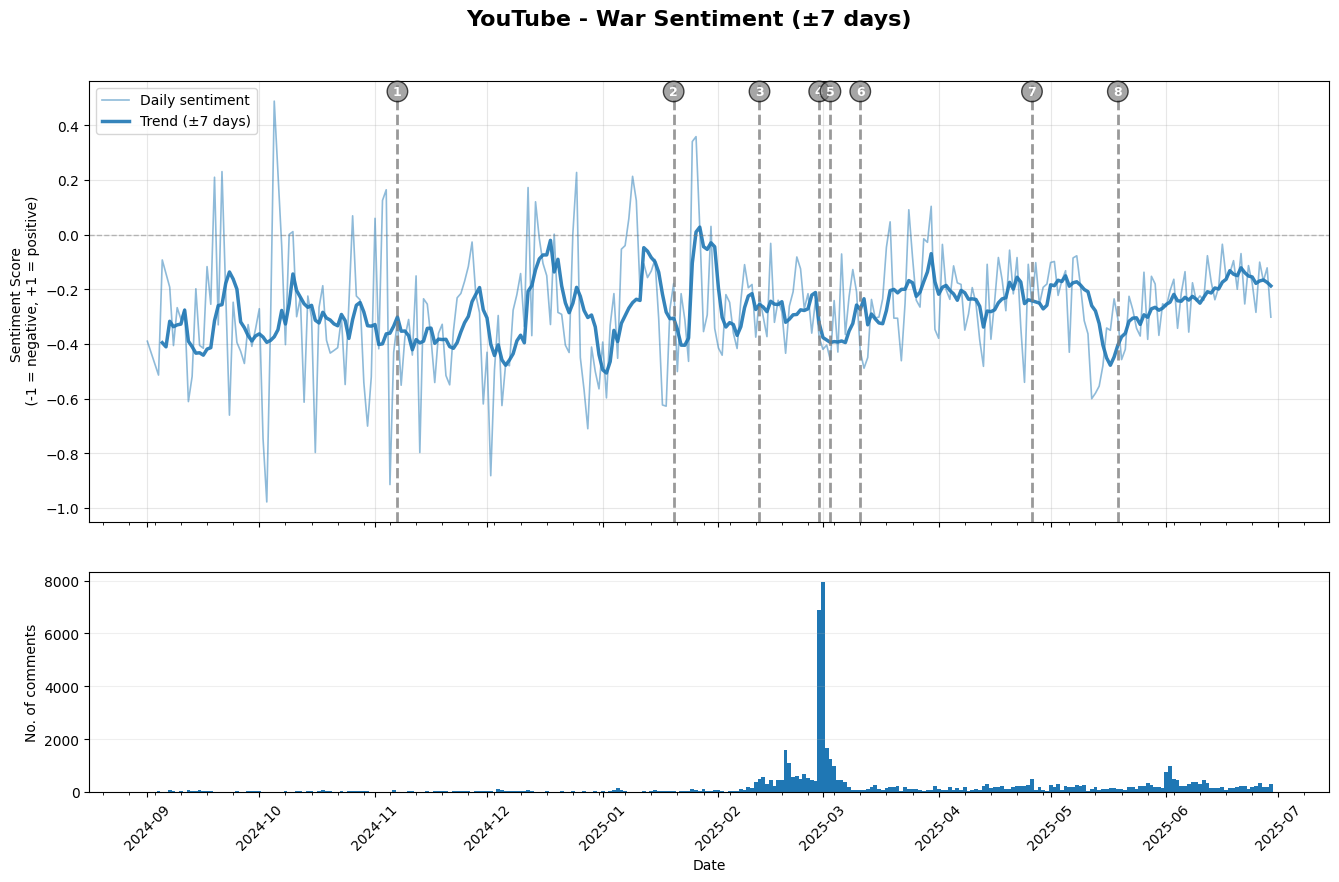


📈 EVENT IMPACT ANALYSIS - YOUTUBE - WAR SENTIMENT (±7 DAYS)
   1) Trump elected (2024-11-07):
     Pre-event:  -0.251 (68 comments)     Post-event: -0.396 (145 comments)
     Change:     -0.145 📉 
   2) Trump inauguration (2025-01-20):
     Pre-event:  -0.314 (275 comments)     Post-event: +0.009 (329 comments)
     Change:     +0.323 📈 ***
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.214 (612 comments)     Post-event: -0.245 (2993 comments)
     Change:     -0.032 📉 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.208 (3275 comments)     Post-event: -0.389 (19637 comments)
     Change:     -0.181 📉 ***
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.384 (16882 comments)     Post-event: -0.325 (3790 comments)
     Change:     +0.059 📈 ***
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.259 (2543 comments)     Post-event: -0.326 (913 comments)
     Change:     -0.067 📉 
   7) Trump-Zelensky meeting (Pope funer

In [53]:
# === SINGLE CELL: YouTube - War Sentiment===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

print("🎯 CHART 5: YouTube - War Sentiment")

# Fallback events if missing
if 'key_events' not in globals():
    key_events = {}

# Fallback for create_event_windows if it doesn't already exist
if 'create_event_windows' not in globals():
    def create_event_windows(events_dict, window_days=3):
        event_windows = {}
        for event_name, event_date in events_dict.items():
            d = pd.to_datetime(event_date)
            event_windows[event_name] = {
                'event': d,
                'before_start': d - timedelta(days=window_days),
                'before_end':   d - timedelta(days=1),
                'after_start':  d,
                'after_end':    d + timedelta(days=window_days)
            }
        return event_windows

# --- compute simple and weighted 7-day trends (time-based rolling) ---
def _add_trends_7d_compare(timeline_data, date_column):
    td = timeline_data.copy().sort_values(date_column)
    td = td.dropna(subset=['sentiment_mean'])
    td = td.set_index(date_column)  # required for "7D" rolling

    # Weighted trend: weights = comment_count
    num = (td['sentiment_mean'] * td['comment_count']).rolling('7D', min_periods=3).sum()
    den = td['comment_count'].rolling('7D', min_periods=3).sum()
    td['trend_7d_weighted'] = num / den

    return td.reset_index()

# --- full plot: two panels + events ---
def plot_youtube_war_trends_with_volume(
    timeline_data,
    events_dict,
    date_column='comment_published_at',
    title='YouTube - War Sentiment (7D Trend: simple vs weighted)',
    color='#1f77b4',
    min_comments_for_line=3,
    figsize=(16, 9)
):
    td = _add_trends_7d_compare(timeline_data, date_column).sort_values(date_column)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.15)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Daily line only for "robust" days
    daily_line = td[td['comment_count'] >= min_comments_for_line]
    if not daily_line.empty:
        ax1.plot(daily_line[date_column], daily_line['sentiment_mean'],
                 linewidth=1.2, alpha=0.5, label=f"Daily sentiment", color=color)

    if td['trend_7d_weighted'].notna().any():
        ax1.plot(td[date_column], td['trend_7d_weighted'],
                 linewidth=2.5, alpha=0.9, label='Trend (±7 days)', color=color)

    ax1.axhline(0, linestyle='--', color='gray', alpha=0.5, linewidth=1)
    ax1.set_ylabel('Sentiment Score \n (-1 = negative, +1 = positive)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Numbered events
    event_list = []
    ev_win = create_event_windows(events_dict, window_days=3) if events_dict else {}
    for i, (name, win) in enumerate(ev_win.items(), 1):
        ax1.axvline(win['event'], color='grey', linestyle='--', linewidth=2, alpha=0.8)
        ymax = ax1.get_ylim()[1]
        ax1.annotate(str(name[0]),
                     xy=(win['event'], ymax),
                     xytext=(0, -10), textcoords='offset points',
                     bbox=dict(boxstyle='circle,pad=0.3', fc='grey', alpha=0.7),
                     fontsize=9, ha='center', fontweight='bold', color='white')
        event_list.append(f"{i} = {name}")

    # X axis (dates)
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())

    # Volume histogram
    ax2.bar(td[date_column], td['comment_count'], width=1.0)
    ax2.set_ylabel('No. of comments')
    ax2.set_xlabel('Date')
    ax2.grid(True, axis='y', alpha=0.2)

    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    out_path = f"results/{title.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')

    return fig, (event_list, out_path)

# === RUN ===
if 'timeline_guerra_youtube' not in globals():
    if 'youtube_data' in globals() and not youtube_data.empty:
        timeline_guerra_youtube = prepare_sentiment_timeline_data(
            youtube_data, 'comment_published_at', 'sentiment_numeric'
        )
    else:
        raise RuntimeError("Missing 'youtube_data' or it is empty.")

fig5, (event_list, img_path) = plot_youtube_war_trends_with_volume(
    timeline_data=timeline_guerra_youtube,
    events_dict=key_events,
    date_column='comment_published_at',
    title='YouTube - War Sentiment (±7 days)',
    color='#1f77b4',
    min_comments_for_line=3,
    figsize=(16, 9)
)

print("Figure saved to:", img_path)
plt.show()

# Impact analysis on actual comments (±7 days) — includes p-value
impact_youtube_war_7d = analyze_single_sentiment_impact(
    df=youtube_data,
    events_dict=key_events,
    date_column='comment_published_at',
    sentiment_column='sentiment_numeric',
    sentiment_name='YouTube - War Sentiment (±7 days)',
    window_days=7
)

# Compact table with p-value
if isinstance(impact_youtube_war_7d, dict) and impact_youtube_war_7d:
    impact_df = (pd.DataFrame.from_dict(impact_youtube_war_7d, orient='index')
                    .reset_index().rename(columns={'index':'event'}))
    cols = ["event","pre","post","change","pre_count","post_count","p_value","significance"]
    impact_df = impact_df[cols]
    print("\n🧪 Event impact (±7 days) on sentiment_numeric (YouTube):")
    print(impact_df.round({"pre":3,"post":3,"change":3,"p_value":4}).to_string(index=False))
else:
    print("\nNo impact results available (insufficient data in the windows).")


     ✓ 146 days with data


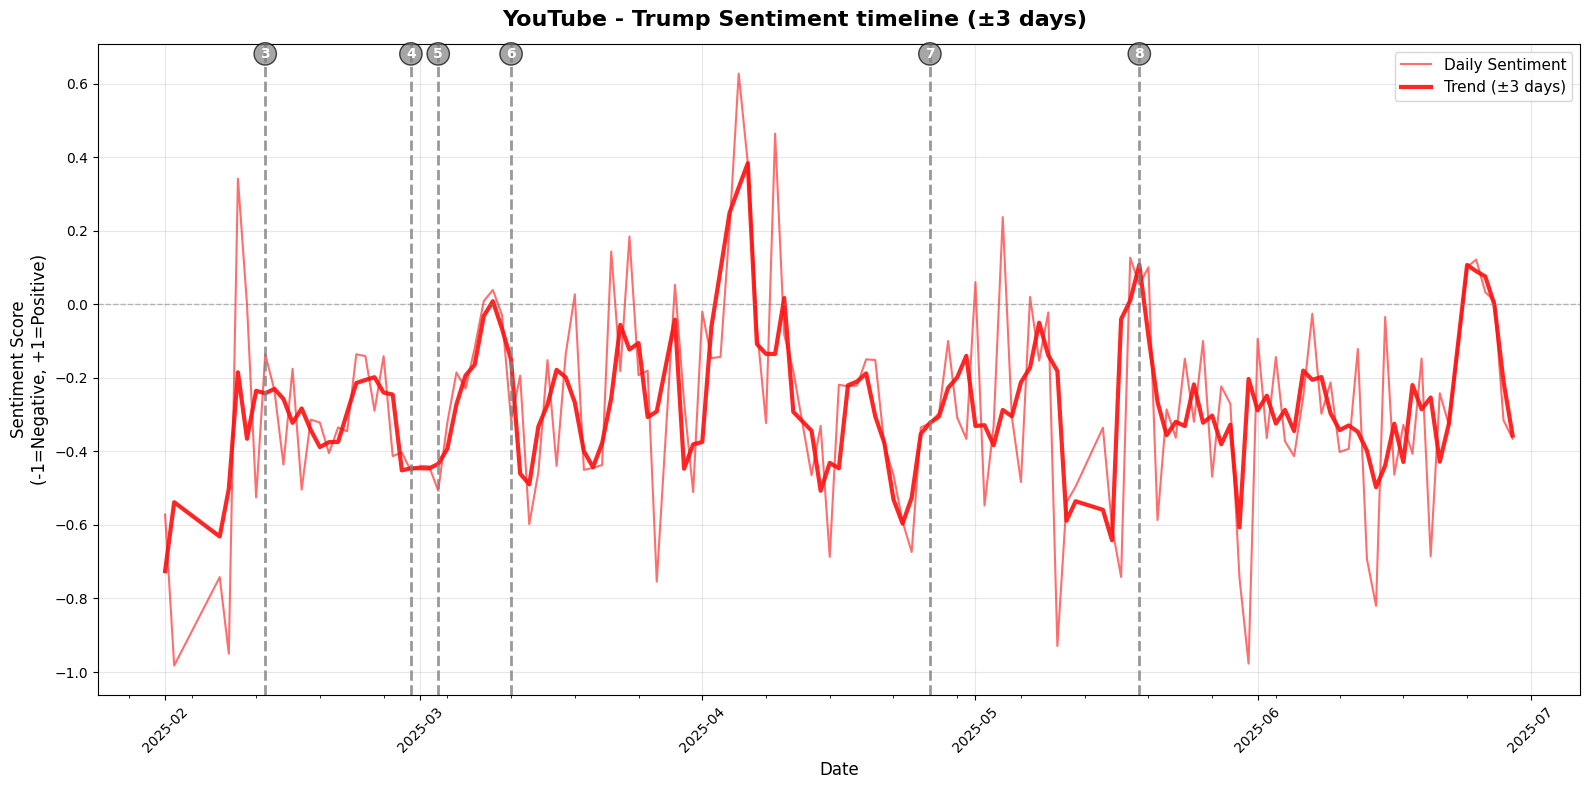


📈 EVENT IMPACT ANALYSIS - YOUTUBE - TRUMP SENTIMENT
   3) Trump calls Putin (2025-02-12):
     Pre-event:  +0.113 (18 comments)     Post-event: -0.230 (348 comments)
     Change:     -0.343 📉 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.204 (316 comments)     Post-event: -0.446 (9605 comments)
     Change:     -0.241 📉 ***
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.446 (8756 comments)     Post-event: -0.393 (1229 comments)
     Change:     +0.053 📈 *
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  +0.024 (88 comments)     Post-event: -0.461 (79 comments)
     Change:     -0.485 📉 ***
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
     Pre-event:  -0.614 (116 comments)     Post-event: -0.305 (400 comments)
     Change:     +0.310 📈 ***
   8) Second Trump-Putin call (2025-05-19):
     Pre-event:  -0.699 (16 comments)     Post-event: -0.086 (42 comments)
     Change:     +0.613 📈 *


In [60]:
# CHART 6: YOUTUBE - TRUMP SENTIMENT

if 'youtube_data_cut' in locals() and not youtube_data_cut.empty:
    # Prepare data
    timeline_trump_youtube = prepare_sentiment_timeline_data(
        youtube_data_cut, 
        'comment_published_at', 
        'trump_sentiment'
    )
    
    # Create chart
    fig6, event_list = plot_single_sentiment_timeline(
        timeline_data=timeline_trump_youtube,
        events_dict=key_events2,
        date_column='comment_published_at',
        sentiment_name='Trump Sentiment',
        color="#ff0e0e",
        title='YouTube - Trump Sentiment timeline (±3 days)',
        figsize=(16, 8)
    )
    
    plt.show()
    
    # Impact analysis
    impact6 = analyze_single_sentiment_impact(
        df=youtube_data_cut,
        events_dict=key_events2, 
        date_column='comment_published_at',
        sentiment_column='trump_sentiment',
        sentiment_name='YouTube - Trump Sentiment'
    )
   
else:
    print("❌ Dataset youtube_data_cut not found")

Figure saved to: results/YouTube_-_Trump_Sentiment_7D.png


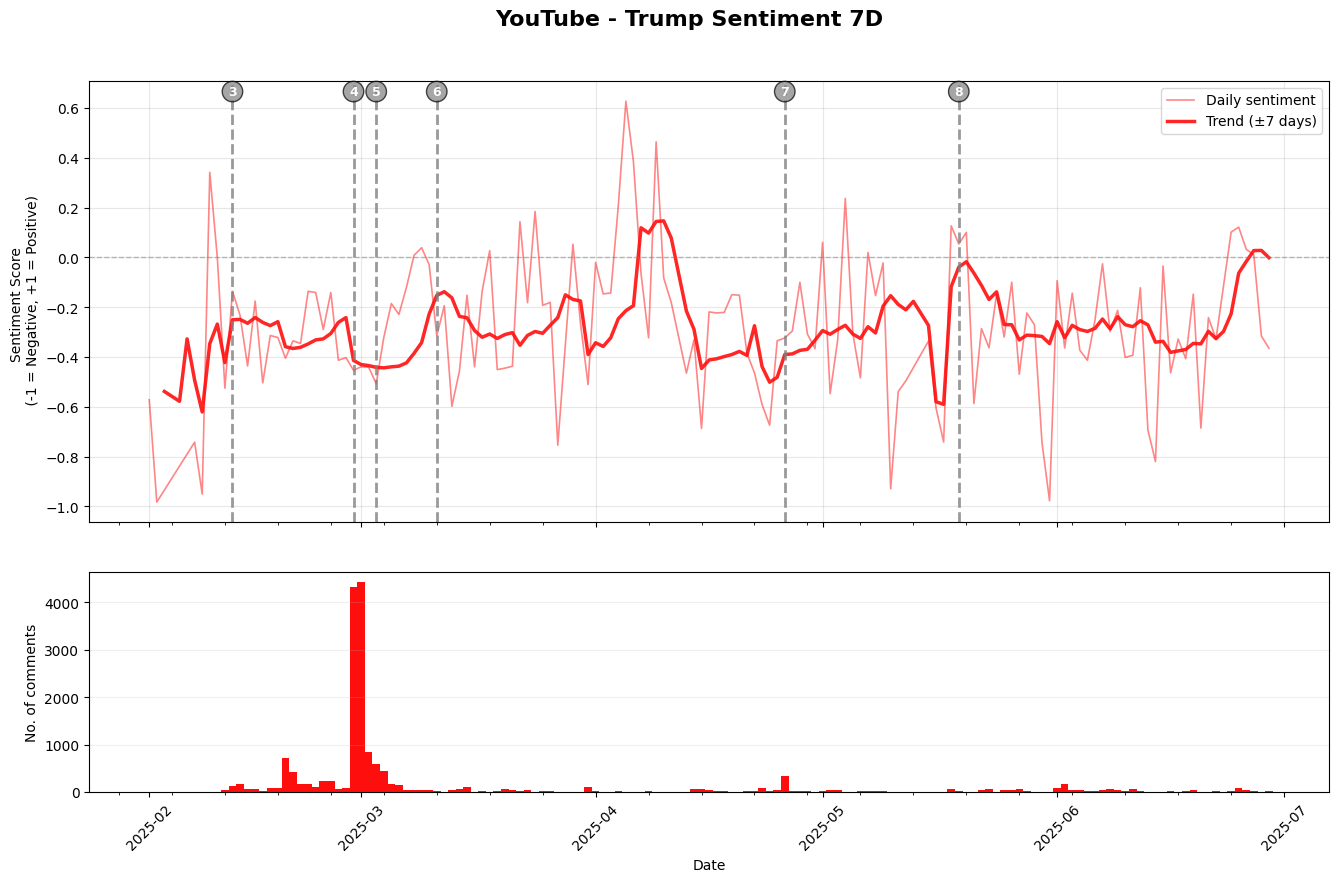


📈 EVENT IMPACT ANALYSIS - YOUTUBE - TRUMP SENTIMENT (±7 DAYS)
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.268 (36 comments)     Post-event: -0.258 (614 comments)
     Change:     +0.010 📈 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.228 (984 comments)     Post-event: -0.437 (10991 comments)
     Change:     -0.208 📉 ***
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.434 (9380 comments)     Post-event: -0.342 (1530 comments)
     Change:     +0.092 📈 ***
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.234 (926 comments)     Post-event: -0.320 (270 comments)
     Change:     -0.086 📉 
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
     Pre-event:  -0.527 (173 comments)     Post-event: -0.308 (481 comments)
     Change:     +0.219 📈 **
   8) Second Trump-Putin call (2025-05-19):
     Pre-event:  -0.598 (32 comments)     Post-event: -0.269 (196 comments)
     Change:     +0.329 📈 

🧪 Event impact

In [63]:
# === SINGLE CELL: YouTube - Trump Sentiment ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Fallback events if missing
if 'key_events' not in globals():
    key_events = {}

# Fallback for create_event_windows if it doesn't already exist
if 'create_event_windows' not in globals():
    def create_event_windows(events_dict, window_days=3):
        event_windows = {}
        for event_name, event_date in events_dict.items():
            d = pd.to_datetime(event_date)
            event_windows[event_name] = {
                'event': d,
                'before_start': d - timedelta(days=window_days),
                'before_end':   d - timedelta(days=1),
                'after_start':  d,
                'after_end':    d + timedelta(days=window_days)
            }
        return event_windows

# --- compute simple and weighted 7-day trends (time-based rolling) ---
def _add_trends_7d_compare(timeline_data, date_column):
    td = timeline_data.copy().sort_values(date_column)
    td = td.dropna(subset=['sentiment_mean'])
    td = td.set_index(date_column)  # required for "7D" rolling

    # Weighted trend: weights = comment_count
    num = (td['sentiment_mean'] * td['comment_count']).rolling('7D', min_periods=3).sum()
    den = td['comment_count'].rolling('7D', min_periods=3).sum()
    td['trend_7d_weighted'] = num / den

    return td.reset_index()

# --- full plot: two panels + events ---
def plot_youtube_trump_trends_with_volume(
    timeline_data,
    events_dict,
    date_column='comment_published_at',
    title='YouTube - Trump Sentiment timeline',
    color='#ff0e0e',
    min_comments_for_line=3,
    figsize=(16, 9)
):
    td = _add_trends_7d_compare(timeline_data, date_column).sort_values(date_column)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.15)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Daily line only for "robust" days
    daily_line = td[td['comment_count'] >= min_comments_for_line]
    if not daily_line.empty:
        ax1.plot(daily_line[date_column], daily_line['sentiment_mean'],
                 linewidth=1.2, alpha=0.5, label=f"Daily sentiment", color=color)

    if td['trend_7d_weighted'].notna().any():
        ax1.plot(td[date_column], td['trend_7d_weighted'],
                 linewidth=2.5, alpha=0.9, label='Trend (±7 days)', color=color)

    ax1.axhline(0, linestyle='--', color='gray', alpha=0.5, linewidth=1)
    ax1.set_ylabel('Sentiment Score \n (-1 = Negative, +1 = Positive)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # Numbered events
    event_list = []
    ev_win = create_event_windows(events_dict, window_days=3) if events_dict else {}
    for i, (name, win) in enumerate(ev_win.items(), 1):
        ax1.axvline(win['event'], color='grey', linestyle='--', linewidth=2, alpha=0.8)
        ymax = ax1.get_ylim()[1]
        ax1.annotate(str(name[0]),
                     xy=(win['event'], ymax),
                     xytext=(0, -10), textcoords='offset points',
                     bbox=dict(boxstyle='circle,pad=0.3', fc='grey', alpha=0.7),
                     fontsize=9, ha='center', fontweight='bold', color='white')
        event_list.append(f"{i} = {name}")

    # X axis (dates)
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())

    # Volume histogram
    ax2.bar(td[date_column], td['comment_count'], width=1.0, color = '#ff0e0e')
    ax2.set_ylabel('No. of comments')
    ax2.set_xlabel('Date')
    ax2.grid(True, axis='y', alpha=0.2)

    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    out_path = f"results/{title.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')

    return fig, (event_list, out_path)

# === RUN ===
if 'timeline_trump_youtube' not in globals():
    if 'youtube_data_cut' in globals() and not youtube_data_cut.empty:
        timeline_trump_youtube = prepare_sentiment_timeline_data(
            youtube_data_cut, 'comment_published_at', 'trump_sentiment'
        )
    else:
        raise RuntimeError("Missing 'youtube_data_cut' or it is empty.")

fig6, (event_list, img_path) = plot_youtube_trump_trends_with_volume(
    timeline_data=timeline_trump_youtube,
    events_dict=key_events2,
    date_column='comment_published_at',
    title='YouTube - Trump Sentiment 7D',
    color='#ff0e0e',
    min_comments_for_line=3,
    figsize=(16, 9)
)

print("Figure saved to:", img_path)
plt.show()

# Impact analysis on actual comments (±7 days) — includes p-value
impact_youtube_trump_7d = analyze_single_sentiment_impact(
    df=youtube_data_cut,
    events_dict=key_events2,
    date_column='comment_published_at',
    sentiment_column='trump_sentiment',
    sentiment_name='YouTube - Trump Sentiment (±7 days)',
    window_days=7
)

# Compact table with p-value
if isinstance(impact_youtube_trump_7d, dict) and impact_youtube_trump_7d:
    impact_df = (pd.DataFrame.from_dict(impact_youtube_trump_7d, orient='index')
                    .reset_index().rename(columns={'index':'event'}))
    cols = ["event","pre","post","change","pre_count","post_count","p_value","significance"]
    impact_df = impact_df[cols]
    print("\n🧪 Event impact (±7 days) on trump_sentiment (YouTube):")
    print(impact_df.round({"pre":3,"post":3,"change":3,"p_value":4}).to_string(index=False))
else:
    print("\nNo impact results available (insufficient data in the windows).")


     ✓ 146 days with data


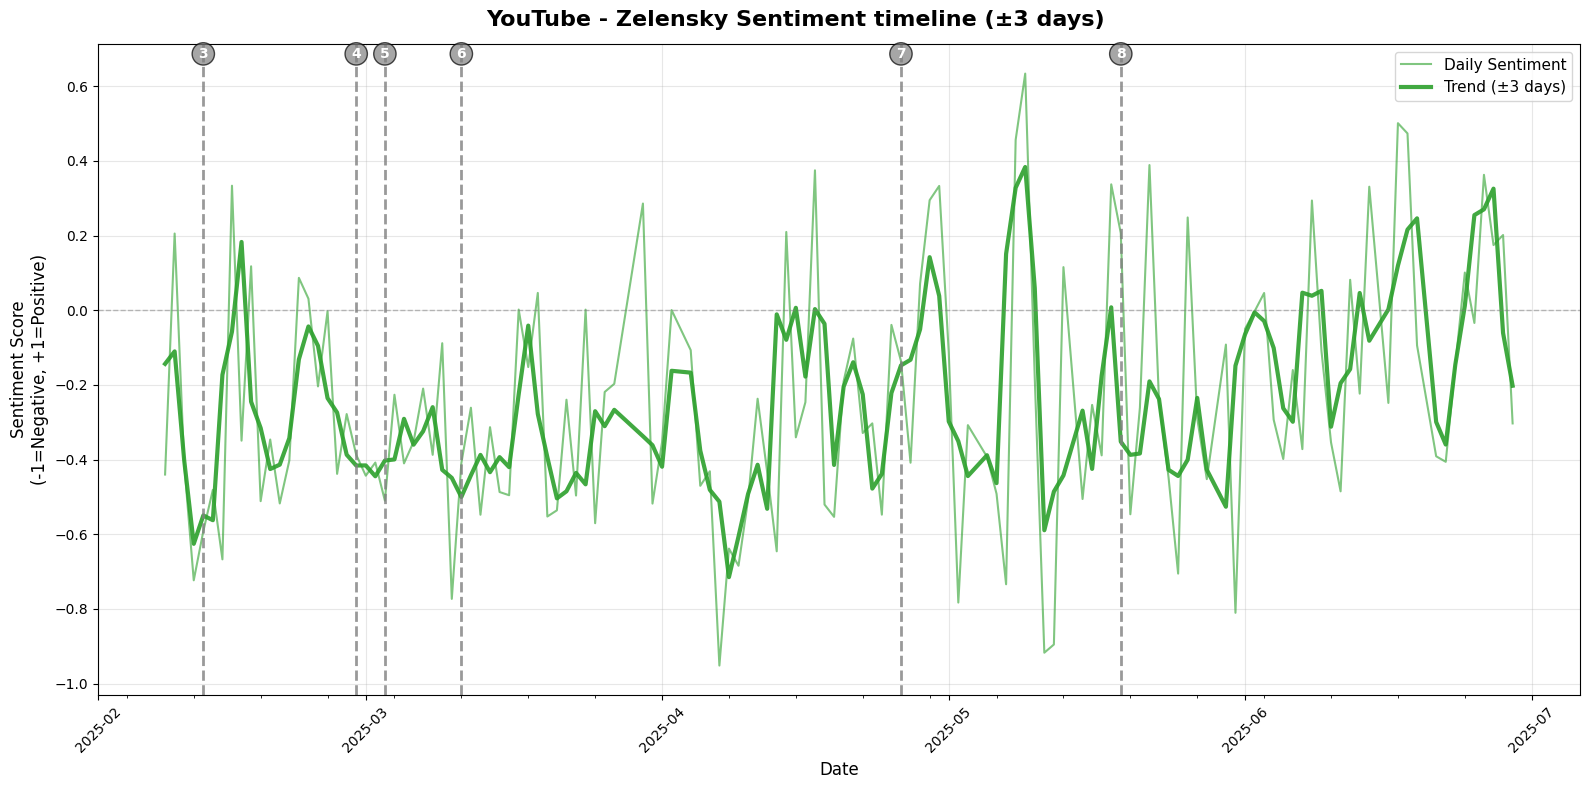


📈 EVENT IMPACT ANALYSIS - YOUTUBE - ZELENSKY SENTIMENT
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.000 (12 comments)     Post-event: -0.562 (100 comments)
     Change:     -0.562 📉 *
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.272 (63 comments)     Post-event: -0.416 (7939 comments)
     Change:     -0.143 📉 
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.416 (7232 comments)     Post-event: -0.400 (942 comments)
     Change:     +0.017 📈 
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.297 (53 comments)     Post-event: -0.442 (67 comments)
     Change:     -0.145 📉 
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
     Pre-event:  -0.483 (80 comments)     Post-event: -0.133 (239 comments)
     Change:     +0.351 📈 **
   8) Second Trump-Putin call (2025-05-19):
     Pre-event:  -0.315 (11 comments)     Post-event: -0.387 (38 comments)
     Change:     -0.072 📉 


In [65]:
# CHART 7: YOUTUBE - ZELENSKY SENTIMENT

if 'youtube_data_cut' in locals() and not youtube_data_cut.empty:
    # Prepare data
    timeline_zelensky_youtube = prepare_sentiment_timeline_data(
        youtube_data_cut, 
        'comment_published_at', 
        'zelensky_sentiment'
    )
    
    # Create chart
    fig7, event_list = plot_single_sentiment_timeline(
        timeline_data=timeline_zelensky_youtube,
        events_dict=key_events2,
        date_column='comment_published_at',
        sentiment_name='Zelensky Sentiment',
        color='#2ca02c',
        title='YouTube - Zelensky Sentiment timeline (±3 days)',
        figsize=(16, 8)
    )
    
    plt.show()
    
    # Impact analysis
    impact7 = analyze_single_sentiment_impact(
        df=youtube_data_cut,
        events_dict=key_events2, 
        date_column='comment_published_at',
        sentiment_column='zelensky_sentiment',
        sentiment_name='YouTube - Zelensky Sentiment'
    )

else:
    print("❌ Dataset youtube_data_cut not found")

Figure saved to: results/YouTube_-_Zelensky_Sentiment_timeline_(±7_days).png


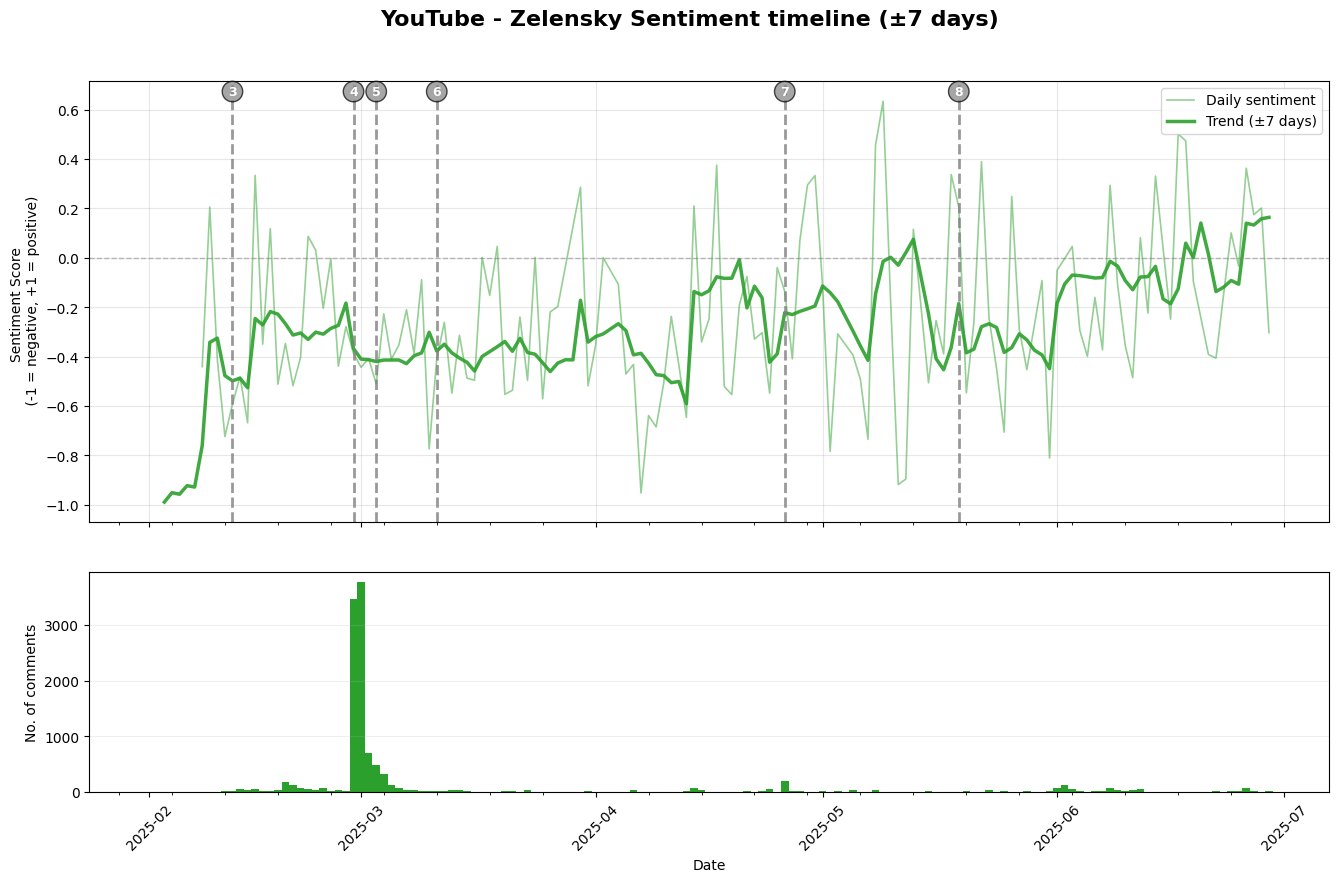


📈 EVENT IMPACT ANALYSIS - YOUTUBE - ZELENSKY SENTIMENT (±7 DAYS)
   3) Trump calls Putin (2025-02-12):
     Pre-event:  -0.300 (21 comments)     Post-event: -0.228 (239 comments)
     Change:     +0.073 📈 
   4) Trump-Zelensky-Vance meeting (2025-02-28):
     Pre-event:  -0.175 (328 comments)     Post-event: -0.413 (8960 comments)
     Change:     -0.238 📉 ***
   5) Suspension of military aid (2025-03-03):
     Pre-event:  -0.413 (7397 comments)     Post-event: -0.385 (1114 comments)
     Change:     +0.028 📈 
   6) 30-day ceasefire + aid restored (2025-03-11):
     Pre-event:  -0.286 (624 comments)     Post-event: -0.399 (154 comments)
     Change:     -0.113 📉 
   7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
     Pre-event:  -0.419 (106 comments)     Post-event: -0.141 (274 comments)
     Change:     +0.278 📈 **
   8) Second Trump-Putin call (2025-05-19):
     Pre-event:  -0.411 (44 comments)     Post-event: -0.383 (107 comments)
     Change:     +0.028 📈 

🧪 Event impact 

In [68]:
# === SINGLE CELL: YouTube - Zelensky Sentiment===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Fallback events
if 'key_events' not in globals():
    key_events = {}

# Fallback create_event_windows function
if 'create_event_windows' not in globals():
    def create_event_windows(events_dict, window_days=3):
        ev = {}
        for name, d in events_dict.items():
            d = pd.to_datetime(d)
            ev[name] = {
                'event': d,
                'before_start': d - timedelta(days=window_days),
                'before_end':   d - timedelta(days=1),
                'after_start':  d,
                'after_end':    d + timedelta(days=window_days)
            }
        return ev

# --- 7-day simple and weighted trend helper ---
def _add_trends_7d_compare(timeline_data, date_column):
    td = timeline_data.copy().sort_values(date_column)
    td = td.dropna(subset=['sentiment_mean'])
    td = td.set_index(date_column)

    td['trend_7d_simple'] = td['sentiment_mean'].rolling('7D', min_periods=3).mean()
    num = (td['sentiment_mean'] * td['comment_count']).rolling('7D', min_periods=3).sum()
    den = td['comment_count'].rolling('7D', min_periods=3).sum()
    td['trend_7d_weighted'] = num / den

    return td.reset_index()

# --- Plot function: two panels + events ---
def plot_youtube_zelensky_trends_with_volume(
    timeline_data,
    events_dict,
    date_column='comment_published_at',
    title='YouTube - Zelensky Sentiment timeline (±7 days)',
    color='#2ca02c',
    min_comments_for_line=3,
    figsize=(16, 9)
):
    td = _add_trends_7d_compare(timeline_data, date_column).sort_values(date_column)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.15)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Daily sentiment (only days with enough comments)
    daily_line = td[td['comment_count'] >= min_comments_for_line]
    if not daily_line.empty:
        ax1.plot(daily_line[date_column], daily_line['sentiment_mean'],
                 linewidth=1.2, alpha=0.5, label=f"Daily sentiment", color=color)

    if td['trend_7d_weighted'].notna().any():
        ax1.plot(td[date_column], td['trend_7d_weighted'],
                 linewidth=2.5, alpha=0.9, label='Trend (±7 days)', color=color)

    ax1.axhline(0, linestyle='--', color='gray', alpha=0.5, linewidth=1)
    ax1.set_ylabel('Sentiment Score \n (-1 = negative, +1 = positive)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # Events
    event_list = []
    ev_win = create_event_windows(events_dict, window_days=3) if events_dict else {}
    for i, (name, win) in enumerate(ev_win.items(), 1):
        ax1.axvline(win['event'], color='grey', linestyle='--', linewidth=2, alpha=0.8)
        ymax = ax1.get_ylim()[1]
        ax1.annotate(str(name[0]),
                     xy=(win['event'], ymax),
                     xytext=(0, -10), textcoords='offset points',
                     bbox=dict(boxstyle='circle,pad=0.3', fc='grey', alpha=0.7),
                     fontsize=9, ha='center', fontweight='bold', color='white')
        event_list.append(f"{i} = {name}")

    # X axis
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())

    # Comment volume
    ax2.bar(td[date_column], td['comment_count'], width=1.0, color = '#2ca02c')
    ax2.set_ylabel('No. of comments')
    ax2.set_xlabel('Date')
    ax2.grid(True, axis='y', alpha=0.2)

    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    out_path = f"results/{title.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')

    return fig, (event_list, out_path)

# === RUN ===
if 'timeline_zelensky_youtube' not in globals():
    if 'youtube_data_cut' in globals() and not youtube_data_cut.empty:
        timeline_zelensky_youtube = prepare_sentiment_timeline_data(
            youtube_data_cut, 'comment_published_at', 'zelensky_sentiment'
        )
    else:
        raise RuntimeError("Missing 'youtube_data_cut' or it is empty.")

fig7, (event_list, img_path) = plot_youtube_zelensky_trends_with_volume(
    timeline_data=timeline_zelensky_youtube,
    events_dict=key_events2,
    date_column='comment_published_at',
    title='YouTube - Zelensky Sentiment timeline (±7 days)',
    color='#2ca02c',
    min_comments_for_line=3,
    figsize=(16, 9)
)

print("Figure saved to:", img_path)
plt.show()

# ±7 days impact analysis
impact_youtube_zelensky_7d = analyze_single_sentiment_impact(
    df=youtube_data_cut,
    events_dict=key_events2,
    date_column='comment_published_at',
    sentiment_column='zelensky_sentiment',
    sentiment_name='YouTube - Zelensky Sentiment (±7 days)',
    window_days=7
)

# Output with p-values
if isinstance(impact_youtube_zelensky_7d, dict) and impact_youtube_zelensky_7d:
    impact_df = (pd.DataFrame.from_dict(impact_youtube_zelensky_7d, orient='index')
                    .reset_index().rename(columns={'index':'event'}))
    cols = ["event","pre","post","change","pre_count","post_count","p_value","significance"]
    impact_df = impact_df[cols]
    print("\n🧪 Event impact (±7 days) on zelensky_sentiment (YouTube):")
    print(impact_df.round({"pre":3,"post":3,"change":3,"p_value":4}).to_string(index=False))
else:
    print("\nNo impact results available (insufficient data in the windows).")


In [78]:
# # GRAFICO 8: YOUTUBE - SENTIMENT PEACE

# print("🕊️ GRAFICO 8: YouTube - Sentiment verso la Pace")

# if 'youtube_data_cut' in locals() and not youtube_data_cut.empty:
#     # Prepara dati
#     timeline_peace_youtube = prepare_sentiment_timeline_data(
#         youtube_data_cut, 
#         'comment_published_at', 
#         'peace_sentiment'
#     )
    
#     # Crea grafico
#     fig8, event_list = plot_single_sentiment_timeline(
#         timeline_data=timeline_peace_youtube,
#         events_dict=key_events2,
#         date_column='comment_published_at',
#         sentiment_name='Sentiment Peace',
#         color='#d62728',
#         title='YouTube - Sentiment verso la Pace',
#         figsize=(16, 8)
#     )
    
#     plt.show()
    
#     # Analisi impatto
#     impact8 = analyze_single_sentiment_impact(
#         df=youtube_data_cut,
#         events_dict=key_events2, 
#         date_column='comment_published_at',
#         sentiment_column='peace_sentiment',
#         sentiment_name='Youtube - Sentiment Pace'
#     )
    
# else:
#     print("❌ Dataset youtube_data_cut non trovato")

## 9. Salvataggio dei Risultati

In [69]:
import os

# Create results folder if it does not exist
os.makedirs('results', exist_ok=True)

# Save processed datasets with sentiment
print("💾 Saving results...")

if not reddit_relevance.empty:
    reddit_relevance.to_csv('results/reddit_relevance_with_sentiment.csv', index=False)
    print("✓ Reddit RELEVANCE saved")

if not youtube_data.empty:
    youtube_data.to_csv('results/youtube_with_sentiment.csv', index=False)
    print("✓ YouTube saved")

print("\n🎉 DATA SAVED!")
print("📁 All files have been saved in the 'results/' folder")

💾 Saving results...
✓ Reddit RELEVANCE saved
✓ YouTube saved

🎉 DATA SAVED!
📁 All files have been saved in the 'results/' folder


## 10. Statistical Analysis of Events

In [82]:
def analyze_events_simple(df, dataset_name):
    """Simple event analysis with descriptive statistics"""
    if df.empty:
        print(f"❌ {dataset_name}: Empty dataset")
        return None
    
    date_col = 'comment_created_utc' if 'comment_created_utc' in df.columns else 'comment_published_at'
    if date_col not in df.columns:
        print(f"❌ {dataset_name}: Date column not found")
        return None
    
    # Filter only comments with computed sentiment (war keywords)
    sentiment_comments = df.dropna(subset=['sentiment_numeric'])
    
    if sentiment_comments.empty:
        print(f"❌ {dataset_name}: No comments with sentiment")
        return None
    
    print(f"\n📊 EVENT ANALYSIS - {dataset_name}")
    print("=" * 50)
    
    results = []
    
    for event_name, event_date_str in key_events.items():
        event_date = pd.to_datetime(event_date_str).tz_localize(None)
        
        # 3-day window before and after
        before_start = event_date - timedelta(days=3)
        before_end = event_date - timedelta(days=1)
        after_start = event_date
        after_end = event_date + timedelta(days=3)
        
        # Filter comments
        before_comments = sentiment_comments[
            (sentiment_comments[date_col] >= before_start) & 
            (sentiment_comments[date_col] <= before_end)
        ]
        
        after_comments = sentiment_comments[
            (sentiment_comments[date_col] >= after_start) & 
            (sentiment_comments[date_col] <= after_end)
        ]
        
        if len(before_comments) < 5 or len(after_comments) < 5:
            print(f"⚠️ {event_name}: Insufficient data")
            continue
        
        # Compute statistics
        sentiment_before = before_comments['sentiment_numeric'].mean()
        sentiment_after = after_comments['sentiment_numeric'].mean()
        change = sentiment_after - sentiment_before
        
        # Convert and clean data before t-test
        before_comments['sentiment_numeric'] = pd.to_numeric(before_comments['sentiment_numeric'], errors='coerce')
        after_comments['sentiment_numeric'] = pd.to_numeric(after_comments['sentiment_numeric'], errors='coerce')

        # Drop NaNs
        before_comments = before_comments.dropna(subset=['sentiment_numeric'])
        after_comments = after_comments.dropna(subset=['sentiment_numeric'])

        # Simple statistical test (t-test)
        from scipy.stats import ttest_ind
        t_stat, p_value = ttest_ind(before_comments['sentiment_numeric'], 
                                   after_comments['sentiment_numeric'])
        
        print(f"\n📅 {event_name} ({event_date_str}):")
        print(f"   Before (3d): {sentiment_before:.3f} ({len(before_comments)} comments)")
        print(f"   After (3d):  {sentiment_after:.3f} ({len(after_comments)} comments)")
        print(f"   Change:      {change:+.3f}")
        print(f"   Significance: p={p_value:.3f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'n.s.'}")
        
        results.append({
            'dataset': dataset_name,
            'event': event_name,
            'date': event_date_str,
            'sentiment_before': sentiment_before,
            'sentiment_after': sentiment_after,
            'change': change,
            'comments_before': len(before_comments),
            'comments_after': len(after_comments),
            'p_value': p_value,
            'significant': p_value < 0.05
        })
    
    return pd.DataFrame(results)

# Run event analysis for each dataset
all_event_results = []

if not reddit_relevance.empty:
    reddit_rel_events = analyze_events_simple(reddit_relevance, "Reddit RELEVANCE")
    if reddit_rel_events is not None:
        all_event_results.append(reddit_rel_events)

if not youtube_data.empty:
    youtube_events = analyze_events_simple(youtube_data, "YouTube")
    if youtube_events is not None:
        all_event_results.append(youtube_events)

# Combine all results
if all_event_results:
    combined_events = pd.concat(all_event_results, ignore_index=True)
    combined_events.to_csv('results/events_analysis_combined.csv', index=False)
    print("\n✅ Event analysis saved to: events_analysis_combined_3d.csv")


📊 EVENT ANALYSIS - Reddit RELEVANCE

📅 1) Trump elected (2024-11-07):
   Before (3d): -0.532 (17 comments)
   After (3d):  -0.428 (885 comments)
   Change:      +0.104
   Significance: p=0.621 n.s.

📅 2) Trump inauguration (2025-01-20):
   Before (3d): -0.331 (54 comments)
   After (3d):  -0.571 (519 comments)
   Change:      -0.240
   Significance: p=0.035 *

📅 3) Trump calls Putin (2025-02-12):
   Before (3d): -0.524 (534 comments)
   After (3d):  -0.535 (2116 comments)
   Change:      -0.011
   Significance: p=0.783 n.s.

📅 4) Trump-Zelensky-Vance meeting (2025-02-28):
   Before (3d): -0.483 (1151 comments)
   After (3d):  -0.472 (5563 comments)
   Change:      +0.011
   Significance: p=0.686 n.s.

📅 5) Suspension of military aid (2025-03-03):
   Before (3d): -0.460 (4832 comments)
   After (3d):  -0.507 (3229 comments)
   Change:      -0.047
   Significance: p=0.014 *

📅 6) 30-day ceasefire + aid restored (2025-03-11):
   Before (3d): -0.533 (578 comments)
   After (3d):  -0.519 (

📊 EVENT ANALYSIS - Reddit (3 days)
==================================================

📅 1) Trump elected (2024-11-07):
   Before (3d): -0.532 (17 comments)
   After (3d):  -0.428 (885 comments)
   Change:      +0.104
   Significance: p=0.621 n.s.

📅 2) Trump inauguration (2025-01-20):
   Before (3d): -0.331 (54 comments)
   After (3d):  -0.571 (519 comments)
   Change:      -0.240
   Significance: p=0.035 *

📅 3) Trump calls Putin (2025-02-12):
   Before (3d): -0.524 (534 comments)
   After (3d):  -0.535 (2116 comments)
   Change:      -0.011
   Significance: p=0.783 n.s.

📅 4) Trump-Zelensky-Vance meeting (2025-02-28):
   Before (3d): -0.483 (1151 comments)
   After (3d):  -0.472 (5563 comments)
   Change:      +0.011
   Significance: p=0.686 n.s.

📅 5) Suspension of military aid (2025-03-03):
   Before (3d): -0.460 (4832 comments)
   After (3d):  -0.507 (3229 comments)
   Change:      -0.047
   Significance: p=0.014 *

📅 6) 30-day ceasefire + aid restored (2025-03-11):
   Before (3d): -0.533 (578 comments)
   After (3d):  -0.519 (1556 comments)
   Change:      +0.014
   Significance: p=0.730 n.s.

📅 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
   Before (3d): -0.591 (840 comments)
   After (3d):  -0.470 (666 comments)
   Change:      +0.121
   Significance: p=0.004 **

📅 8) Second Trump-Putin call (2025-05-19):
   Before (3d): -0.520 (218 comments)
   After (3d):  -0.531 (886 comments)
   Change:      -0.011
   Significance: p=0.855 n.s.

📊 EVENT ANALYSIS - YouTube (3 days)
==================================================

📅 1) Trump elected (2024-11-07):
   Before (3d): -0.211 (23 comments)
   After (3d):  -0.413 (56 comments)
   Change:      -0.202
   Significance: p=0.366 n.s.

📅 2) Trump inauguration (2025-01-20):
   Before (3d): -0.626 (95 comments)
   After (3d):  -0.266 (86 comments)
   Change:      +0.359
   Significance: p=0.005 **

📅 3) Trump calls Putin (2025-02-12):
   Before (3d): -0.189 (321 comments)
   After (3d):  -0.291 (1396 comments)
   Change:      -0.101
   Significance: p=0.077 n.s.

📅 4) Trump-Zelensky-Vance meeting (2025-02-28):
   Before (3d): -0.282 (961 comments)
   After (3d):  -0.400 (16498 comments)
   Change:      -0.118
   Significance: p=0.000 ***

📅 5) Suspension of military aid (2025-03-03):
   Before (3d): -0.400 (14819 comments)
   After (3d):  -0.373 (2700 comments)
   Change:      +0.026
   Significance: p=0.150 n.s.

📅 6) 30-day ceasefire + aid restored (2025-03-11):
   Before (3d): -0.198 (269 comments)
   After (3d):  -0.457 (255 comments)
   Change:      -0.260
   Significance: p=0.001 **

📅 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
   Before (3d): -0.443 (440 comments)
   After (3d):  -0.240 (757 comments)
   Change:      +0.202
   Significance: p=0.000 ***

📅 8) Second Trump-Putin call (2025-05-19):
   Before (3d): -0.346 (257 comments)
   After (3d):  -0.384 (318 comments)
   Change:      -0.038
   Significance: p=0.613 n.s.

✅ Event analysis saved to: events_analysis_combined.csv

In [83]:
def analyze_events_simple(df, dataset_name):
    """Simple event analysis with descriptive statistics"""
    if df.empty:
        print(f"❌ {dataset_name}: Empty dataset")
        return None
    
    date_col = 'comment_created_utc' if 'comment_created_utc' in df.columns else 'comment_published_at'
    if date_col not in df.columns:
        print(f"❌ {dataset_name}: Date column not found")
        return None
    
    # Filter only comments with computed sentiment (war keywords)
    sentiment_comments = df.dropna(subset=['sentiment_numeric'])
    
    if sentiment_comments.empty:
        print(f"❌ {dataset_name}: No comments with sentiment")
        return None
    
    print(f"\n📊 EVENT ANALYSIS - {dataset_name}")
    print("=" * 50)
    
    results = []
    
    for event_name, event_date_str in key_events.items():
        event_date = pd.to_datetime(event_date_str).tz_localize(None)
        
        # 7-day window before and after
        before_start = event_date - timedelta(days=7)
        before_end = event_date - timedelta(days=1)
        after_start = event_date
        after_end = event_date + timedelta(days=7)
        
        # Filter comments
        before_comments = sentiment_comments[
            (sentiment_comments[date_col] >= before_start) & 
            (sentiment_comments[date_col] <= before_end)
        ]
        
        after_comments = sentiment_comments[
            (sentiment_comments[date_col] >= after_start) & 
            (sentiment_comments[date_col] <= after_end)
        ]
        
        if len(before_comments) < 5 or len(after_comments) < 5:
            print(f"⚠️ {event_name}: Insufficient data")
            continue
        
        # Compute statistics
        sentiment_before = before_comments['sentiment_numeric'].mean()
        sentiment_after = after_comments['sentiment_numeric'].mean()
        change = sentiment_after - sentiment_before
        
        # Convert and clean data before t-test
        before_comments['sentiment_numeric'] = pd.to_numeric(before_comments['sentiment_numeric'], errors='coerce')
        after_comments['sentiment_numeric'] = pd.to_numeric(after_comments['sentiment_numeric'], errors='coerce')

        # Drop NaNs
        before_comments = before_comments.dropna(subset=['sentiment_numeric'])
        after_comments = after_comments.dropna(subset=['sentiment_numeric'])

        # Simple statistical test (t-test)
        from scipy.stats import ttest_ind
        t_stat, p_value = ttest_ind(before_comments['sentiment_numeric'], 
                                   after_comments['sentiment_numeric'])
        
        print(f"\n📅 {event_name} ({event_date_str}):")
        print(f"   Before (7d): {sentiment_before:.3f} ({len(before_comments)} comments)")
        print(f"   After (7d):  {sentiment_after:.3f} ({len(after_comments)} comments)")
        print(f"   Change:      {change:+.3f}")
        print(f"   Significance: p={p_value:.3f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'n.s.'}")
        
        results.append({
            'dataset': dataset_name,
            'event': event_name,
            'date': event_date_str,
            'sentiment_before': sentiment_before,
            'sentiment_after': sentiment_after,
            'change': change,
            'comments_before': len(before_comments),
            'comments_after': len(after_comments),
            'p_value': p_value,
            'significant': p_value < 0.05
        })
    
    return pd.DataFrame(results)

# Run event analysis for each dataset
all_event_results = []

if not reddit_relevance.empty:
    reddit_rel_events = analyze_events_simple(reddit_relevance, "Reddit RELEVANCE")
    if reddit_rel_events is not None:
        all_event_results.append(reddit_rel_events)

if not youtube_data.empty:
    youtube_events = analyze_events_simple(youtube_data, "YouTube")
    if youtube_events is not None:
        all_event_results.append(youtube_events)

# Combine all results
if all_event_results:
    combined_events = pd.concat(all_event_results, ignore_index=True)
    combined_events.to_csv('results/events_analysis_combined.csv', index=False)
    print("\n✅ Event analysis saved to: events_analysis_combined_7d.csv")



📊 EVENT ANALYSIS - Reddit RELEVANCE

📅 1) Trump elected (2024-11-07):
   Before (7d): -0.569 (425 comments)
   After (7d):  -0.492 (1985 comments)
   Change:      +0.077
   Significance: p=0.079 n.s.

📅 2) Trump inauguration (2025-01-20):
   Before (7d): -0.527 (470 comments)
   After (7d):  -0.501 (1471 comments)
   Change:      +0.026
   Significance: p=0.548 n.s.

📅 3) Trump calls Putin (2025-02-12):
   Before (7d): -0.499 (1193 comments)
   After (7d):  -0.542 (4165 comments)
   Change:      -0.043
   Significance: p=0.107 n.s.

📅 4) Trump-Zelensky-Vance meeting (2025-02-28):
   Before (7d): -0.457 (2934 comments)
   After (7d):  -0.493 (9735 comments)
   Change:      -0.036
   Significance: p=0.043 *

📅 5) Suspension of military aid (2025-03-03):
   Before (7d): -0.461 (6949 comments)
   After (7d):  -0.520 (5409 comments)
   Change:      -0.058
   Significance: p=0.000 ***

📅 6) 30-day ceasefire + aid restored (2025-03-11):
   Before (7d): -0.513 (4298 comments)
   After (7d):  

📊 EVENT ANALYSIS - Reddit (7 days)
==================================================

📅 1) Trump elected (2024-11-07):
   Before (7d): -0.569 (425 comments)
   After (7d):  -0.492 (1985 comments)
   Change:      +0.077
   Significance: p=0.079 n.s.

📅 2) Trump inauguration (2025-01-20):
   Before (7d): -0.527 (470 comments)
   After (7d):  -0.501 (1471 comments)
   Change:      +0.026
   Significance: p=0.548 n.s.

📅 3) Trump calls Putin (2025-02-12):
   Before (7d): -0.499 (1193 comments)
   After (7d):  -0.542 (4165 comments)
   Change:      -0.043
   Significance: p=0.107 n.s.

📅 4) Trump-Zelensky-Vance meeting (2025-02-28):
   Before (7d): -0.457 (2934 comments)
   After (7d):  -0.493 (9735 comments)
   Change:      -0.036
   Significance: p=0.043 *

📅 5) Suspension of military aid (2025-03-03):
   Before (7d): -0.461 (6949 comments)
   After (7d):  -0.520 (5409 comments)
   Change:      -0.058
   Significance: p=0.000 ***

📅 6) 30-day ceasefire + aid restored (2025-03-11):
   Before (7d): -0.513 (4298 comments)
   After (7d):  -0.509 (2502 comments)
   Change:      +0.004
   Significance: p=0.842 n.s.

📅 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
   Before (7d): -0.569 (1122 comments)
   After (7d):  -0.546 (1490 comments)
   Change:      +0.023
   Significance: p=0.467 n.s.

📅 8) Second Trump-Putin call (2025-05-19):
   Before (7d): -0.553 (937 comments)
   After (7d):  -0.561 (1562 comments)
   Change:      -0.008
   Significance: p=0.807 n.s.

📊 EVENT ANALYSIS - YouTube (7 days)
==================================================

📅 1) Trump elected (2024-11-07):
   Before (7d): -0.251 (68 comments)
   After (7d):  -0.396 (145 comments)
   Change:      -0.145
   Significance: p=0.270 n.s.

📅 2) Trump inauguration (2025-01-20):
   Before (7d): -0.314 (275 comments)
   After (7d):  0.009 (329 comments)
   Change:      +0.323
   Significance: p=0.000 ***

📅 3) Trump calls Putin (2025-02-12):
   Before (7d): -0.214 (612 comments)
   After (7d):  -0.245 (2993 comments)
   Change:      -0.032
   Significance: p=0.446 n.s.

📅 4) Trump-Zelensky-Vance meeting (2025-02-28):
   Before (7d): -0.208 (3275 comments)
   After (7d):  -0.389 (19637 comments)
   Change:      -0.181
   Significance: p=0.000 ***

📅 5) Suspension of military aid (2025-03-03):
   Before (7d): -0.384 (16882 comments)
   After (7d):  -0.325 (3790 comments)
   Change:      +0.059
   Significance: p=0.000 ***

📅 6) 30-day ceasefire + aid restored (2025-03-11):
   Before (7d): -0.259 (2543 comments)
   After (7d):  -0.326 (913 comments)
   Change:      -0.067
   Significance: p=0.061 n.s.

📅 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26):
   Before (7d): -0.272 (1056 comments)
   After (7d):  -0.187 (1366 comments)
   Change:      +0.085
   Significance: p=0.027 *

📅 8) Second Trump-Putin call (2025-05-19):
   Before (7d): -0.486 (761 comments)
   After (7d):  -0.329 (1080 comments)
   Change:      +0.158
   Significance: p=0.000 ***

✅ Event analysis saved to: events_analysis_combined_7d.csv

### Event Impact Analysis with Multiple Time Windows (±3, ±7, ±14 days)

This section evaluates how major political events influence sentiment on Reddit and YouTube.  
For each event, we compute the average sentiment before and after the event within three different windows (3, 7, and 14 days).  
We then calculate the change in sentiment and test its statistical significance using a two-sample t-test.


In [91]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from datetime import timedelta

def analyze_event_impact_multiple_windows(df, events_dict, date_column, sentiment_column, dataset_name):
    """
    Analyze the impact of events over multiple time windows (3, 7, 14 days).
    """
    results = []
    df = df.copy()

    # Dates -> datetime naive
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    if hasattr(df[date_column].dtype, 'tz') and df[date_column].dt.tz is not None:
        df[date_column] = df[date_column].dt.tz_localize(None)
    df = df.dropna(subset=[date_column])

    # Sentiment -> numeric float
    df[sentiment_column] = pd.to_numeric(df[sentiment_column], errors='coerce')

    print(f"\n📊 EVENT ANALYSIS - {dataset_name}")
    print("=" * 50)
    
    for event_idx, (event_name, event_date) in enumerate(events_dict.items(), start=1):
        event_date = pd.to_datetime(event_date, errors='coerce')
        if pd.isna(event_date):
            continue
        # make event date naive
        try:
            event_date = event_date.tz_localize(None)
        except Exception:
            pass
        
        for window_days in [3, 7, 14]:
            before_mask = (df[date_column] >= event_date - timedelta(days=window_days)) & \
                          (df[date_column] < event_date)
            after_mask = (df[date_column] >= event_date) & \
                         (df[date_column] <= event_date + timedelta(days=window_days))
            
            # Clean float series
            before_data = df.loc[before_mask, sentiment_column].astype(float).dropna()
            after_data  = df.loc[after_mask,  sentiment_column].astype(float).dropna()
            
            # skip if too few data points
            if len(before_data) < 2 or len(after_data) < 2:
                continue
            
            before_mean = before_data.mean()
            after_mean  = after_data.mean()
            change      = after_mean - before_mean
            
            t_stat, p_value = ttest_ind(after_data, before_data, equal_var=False)
            
            # significance symbol
            if p_value < 0.001:
                signif = "***"
            elif p_value < 0.01:
                signif = "**"
            elif p_value < 0.05:
                signif = "*"
            else:
                signif = "n.s."
            
            print(f"\n📅 {event_idx}) {event_name} ({event_date.date()}), window ±{window_days} days:")
            print(f"   Before ({window_days}d): {before_mean:+.3f} ({len(before_data)} comments)")
            print(f"   After  ({window_days}d): {after_mean:+.3f} ({len(after_data)} comments)")
            print(f"   Change: {change:+.3f}")
            print(f"   Significance: p={p_value:.3f} {signif}")
            
            results.append({
                "dataset": dataset_name,
                "event_index": event_idx,
                "event_name": event_name,
                "event_date": event_date.date(),
                "window_days": window_days,
                "before_mean": before_mean,
                "before_count": len(before_data),
                "after_mean": after_mean,
                "after_count": len(after_data),
                "change": change,
                "p_value": p_value,
                "significance": signif
            })
    
    return pd.DataFrame(results)

# Run for Reddit - War Sentiment
df_res1 = analyze_event_impact_multiple_windows(
    reddit_relevance, key_events,
    date_column='comment_created_utc',
    sentiment_column='sentiment_numeric',
    dataset_name='Reddit - War Sentiment'
)

# Run for YouTube - War Sentiment
df_res2 = analyze_event_impact_multiple_windows(
    youtube_data, key_events,
    date_column='comment_published_at',
    sentiment_column='sentiment_numeric',
    dataset_name='YouTube - War Sentiment'
)

# Merge and save
df_all = pd.concat([df_res1, df_res2], ignore_index=True)
df_all.to_csv("events_analysis_combined.csv", index=False)
print("\n✅ Event analysis saved to: events_analysis_combined.csv")



📊 EVENT ANALYSIS - Reddit - War Sentiment

📅 1) 1) Trump elected (2024-11-07), window ±3 days:
   Before (3d): -0.462 (998 comments)
   After  (3d): -0.428 (885 comments)
   Change: +0.034
   Significance: p=0.386 n.s.

📅 1) 1) Trump elected (2024-11-07), window ±7 days:
   Before (7d): -0.494 (1406 comments)
   After  (7d): -0.492 (1985 comments)
   Change: +0.002
   Significance: p=0.945 n.s.

📅 1) 1) Trump elected (2024-11-07), window ±14 days:
   Before (14d): -0.514 (2196 comments)
   After  (14d): -0.509 (3929 comments)
   Change: +0.006
   Significance: p=0.790 n.s.

📅 2) 2) Trump inauguration (2025-01-20), window ±3 days:
   Before (3d): -0.391 (117 comments)
   After  (3d): -0.571 (519 comments)
   Change: -0.180
   Significance: p=0.045 *

📅 2) 2) Trump inauguration (2025-01-20), window ±7 days:
   Before (7d): -0.517 (533 comments)
   After  (7d): -0.501 (1471 comments)
   Change: +0.016
   Significance: p=0.697 n.s.

📅 2) 2) Trump inauguration (2025-01-20), window ±14 days

📊 EVENT ANALYSIS - Reddit - War Sentiment
==================================================

📅 1) 1) Trump elected (2024-11-07), window ±3 days:
   Before (3d): -0.462 (998 comments)
   After  (3d): -0.428 (885 comments)
   Change: +0.034
   Significance: p=0.386 n.s.

📅 1) 1) Trump elected (2024-11-07), window ±7 days:
   Before (7d): -0.494 (1406 comments)
   After  (7d): -0.492 (1985 comments)
   Change: +0.002
   Significance: p=0.945 n.s.

📅 1) 1) Trump elected (2024-11-07), window ±14 days:
   Before (14d): -0.514 (2196 comments)
   After  (14d): -0.509 (3929 comments)
   Change: +0.006
   Significance: p=0.790 n.s.

📅 2) 2) Trump inauguration (2025-01-20), window ±3 days:
   Before (3d): -0.391 (117 comments)
   After  (3d): -0.571 (519 comments)
   Change: -0.180
   Significance: p=0.045 *

📅 2) 2) Trump inauguration (2025-01-20), window ±7 days:
   Before (7d): -0.517 (533 comments)
   After  (7d): -0.501 (1471 comments)
   Change: +0.016
   Significance: p=0.697 n.s.

📅 2) 2) Trump inauguration (2025-01-20), window ±14 days:
   Before (14d): -0.511 (1696 comments)
   After  (14d): -0.503 (2526 comments)
   Change: +0.008
   Significance: p=0.760 n.s.

📅 3) 3) Trump calls Putin (2025-02-12), window ±3 days:
   Before (3d): -0.528 (616 comments)
   After  (3d): -0.535 (2116 comments)
   Change: -0.007
   Significance: p=0.843 n.s.

📅 3) 3) Trump calls Putin (2025-02-12), window ±7 days:
   Before (7d): -0.502 (1275 comments)
   After  (7d): -0.542 (4165 comments)
   Change: -0.039
   Significance: p=0.133 n.s.

📅 3) 3) Trump calls Putin (2025-02-12), window ±14 days:
   Before (14d): -0.487 (2477 comments)
   After  (14d): -0.506 (9794 comments)
   Change: -0.019
   Significance: p=0.307 n.s.

📅 4) 4) Trump-Zelensky-Vance meeting (2025-02-28), window ±3 days:
   Before (3d): -0.488 (1557 comments)
   After  (3d): -0.472 (5563 comments)
   Change: +0.016
   Significance: p=0.499 n.s.

📅 4) 4) Trump-Zelensky-Vance meeting (2025-02-28), window ±7 days:
   Before (7d): -0.463 (3340 comments)
   After  (7d): -0.493 (9735 comments)
   Change: -0.030
   Significance: p=0.075 n.s.

📅 4) 4) Trump-Zelensky-Vance meeting (2025-02-28), window ±14 days:
   Before (14d): -0.501 (9041 comments)
   After  (14d): -0.498 (12607 comments)
   Change: +0.003
   Significance: p=0.779 n.s.

📅 5) 5) Suspension of military aid (2025-03-03), window ±3 days:
   Before (3d): -0.472 (5563 comments)
   After  (3d): -0.507 (3229 comments)
   Change: -0.035
   Significance: p=0.058 n.s.

📅 5) 5) Suspension of military aid (2025-03-03), window ±7 days:
   Before (7d): -0.470 (7680 comments)
   After  (7d): -0.520 (5409 comments)
   Change: -0.050
   Significance: p=0.001 ***

📅 5) 5) Suspension of military aid (2025-03-03), window ±14 days:
   Before (14d): -0.485 (13339 comments)
   After  (14d): -0.518 (7802 comments)
   Change: -0.033
   Significance: p=0.004 **

📅 6) 6) 30-day ceasefire + aid restored (2025-03-11), window ±3 days:
   Before (3d): -0.524 (657 comments)
   After  (3d): -0.519 (1556 comments)
   Change: +0.005
   Significance: p=0.896 n.s.

📅 6) 6) 30-day ceasefire + aid restored (2025-03-11), window ±7 days:
   Before (7d): -0.512 (4377 comments)
   After  (7d): -0.509 (2502 comments)
   Change: +0.003
   Significance: p=0.878 n.s.

📅 6) 6) 30-day ceasefire + aid restored (2025-03-11), window ±14 days:
   Before (14d): -0.494 (12608 comments)
   After  (14d): -0.532 (5280 comments)
   Change: -0.037
   Significance: p=0.005 **

📅 7) 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26), window ±3 days:
   Before (3d): -0.577 (992 comments)
   After  (3d): -0.470 (666 comments)
   Change: +0.107
   Significance: p=0.009 **

📅 7) 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26), window ±7 days:
   Before (7d): -0.561 (1274 comments)
   After  (7d): -0.546 (1490 comments)
   Change: +0.014
   Significance: p=0.634 n.s.

📅 7) 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26), window ±14 days:
   Before (14d): -0.545 (2770 comments)
   After  (14d): -0.551 (2866 comments)
   Change: -0.006
   Significance: p=0.760 n.s.

📅 8) 8) Second Trump-Putin call (2025-05-19), window ±3 days:
   Before (3d): -0.458 (377 comments)
   After  (3d): -0.531 (886 comments)
   Change: -0.073
   Significance: p=0.155 n.s.

📅 8) 8) Second Trump-Putin call (2025-05-19), window ±7 days:
   Before (7d): -0.527 (1096 comments)
   After  (7d): -0.561 (1562 comments)
   Change: -0.034
   Significance: p=0.281 n.s.

📅 8) 8) Second Trump-Putin call (2025-05-19), window ±14 days:
   Before (14d): -0.561 (2297 comments)
   After  (14d): -0.569 (3341 comments)
   Change: -0.008
   Significance: p=0.705 n.s.

📊 EVENT ANALYSIS - YouTube - War Sentiment
==================================================

📅 1) 1) Trump elected (2024-11-07), window ±3 days:
   Before (3d): -0.370 (83 comments)
   After  (3d): -0.413 (56 comments)
   Change: -0.043
   Significance: p=0.778 n.s.

📅 1) 1) Trump elected (2024-11-07), window ±7 days:
   Before (7d): -0.335 (128 comments)
   After  (7d): -0.396 (145 comments)
   Change: -0.061
   Significance: p=0.572 n.s.

📅 1) 1) Trump elected (2024-11-07), window ±14 days:
   Before (14d): -0.334 (295 comments)
   After  (14d): -0.389 (339 comments)
   Change: -0.055
   Significance: p=0.444 n.s.

📅 2) 2) Trump inauguration (2025-01-20), window ±3 days:
   Before (3d): -0.510 (141 comments)
   After  (3d): -0.266 (86 comments)
   Change: +0.244
   Significance: p=0.047 *

📅 2) 2) Trump inauguration (2025-01-20), window ±7 days:
   Before (7d): -0.308 (321 comments)
   After  (7d): +0.009 (329 comments)
   Change: +0.317
   Significance: p=0.000 ***

📅 2) 2) Trump inauguration (2025-01-20), window ±14 days:
   Before (14d): -0.209 (517 comments)
   After  (14d): -0.171 (781 comments)
   Change: +0.038
   Significance: p=0.481 n.s.

📅 3) 3) Trump calls Putin (2025-02-12), window ±3 days:
   Before (3d): -0.288 (684 comments)
   After  (3d): -0.291 (1396 comments)
   Change: -0.003
   Significance: p=0.948 n.s.

📅 3) 3) Trump calls Putin (2025-02-12), window ±7 days:
   Before (7d): -0.274 (975 comments)
   After  (7d): -0.245 (2993 comments)
   Change: +0.028
   Significance: p=0.406 n.s.

📅 3) 3) Trump calls Putin (2025-02-12), window ±14 days:
   Before (14d): -0.287 (1329 comments)
   After  (14d): -0.262 (8494 comments)
   Change: +0.024
   Significance: p=0.368 n.s.

📅 4) 4) Trump-Zelensky-Vance meeting (2025-02-28), window ±3 days:
   Before (3d): -0.270 (1383 comments)
   After  (3d): -0.400 (16498 comments)
   Change: -0.131
   Significance: p=0.000 ***

📅 4) 4) Trump-Zelensky-Vance meeting (2025-02-28), window ±7 days:
   Before (7d): -0.212 (3697 comments)
   After  (7d): -0.389 (19637 comments)
   Change: -0.177
   Significance: p=0.000 ***

📅 4) 4) Trump-Zelensky-Vance meeting (2025-02-28), window ±14 days:
   Before (14d): -0.266 (8275 comments)
   After  (14d): -0.386 (20630 comments)
   Change: -0.120
   Significance: p=0.000 ***

📅 5) 5) Suspension of military aid (2025-03-03), window ±3 days:
   Before (3d): -0.400 (16498 comments)
   After  (3d): -0.373 (2700 comments)
   Change: +0.027
   Significance: p=0.145 n.s.

📅 5) 5) Suspension of military aid (2025-03-03), window ±7 days:
   Before (7d): -0.386 (18561 comments)
   After  (7d): -0.325 (3790 comments)
   Change: +0.061
   Significance: p=0.000 ***

📅 5) 5) Suspension of military aid (2025-03-03), window ±14 days:
   Before (14d): -0.362 (23769 comments)
   After  (14d): -0.325 (4706 comments)
   Change: +0.037
   Significance: p=0.011 *

📅 6) 6) 30-day ceasefire + aid restored (2025-03-11), window ±3 days:
   Before (3d): -0.200 (356 comments)
   After  (3d): -0.457 (255 comments)
   Change: -0.257
   Significance: p=0.000 ***

📅 6) 6) 30-day ceasefire + aid restored (2025-03-11), window ±7 days:
   Before (7d): -0.258 (2630 comments)
   After  (7d): -0.326 (913 comments)
   Change: -0.068
   Significance: p=0.052 n.s.

📅 6) 6) 30-day ceasefire + aid restored (2025-03-11), window ±14 days:
   Before (14d): -0.378 (21758 comments)
   After  (14d): -0.239 (2044 comments)
   Change: +0.139
   Significance: p=0.000 ***

📅 7) 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26), window ±3 days:
   Before (3d): -0.316 (710 comments)
   After  (3d): -0.240 (757 comments)
   Change: +0.075
   Significance: p=0.119 n.s.

📅 7) 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26), window ±7 days:
   Before (7d): -0.239 (1326 comments)
   After  (7d): -0.187 (1366 comments)
   Change: +0.052
   Significance: p=0.154 n.s.

📅 7) 7) Trump-Zelensky meeting (Pope funeral) (2025-04-26), window ±14 days:
   Before (14d): -0.237 (2720 comments)
   After  (14d): -0.186 (2825 comments)
   Change: +0.051
   Significance: p=0.044 *

📅 8) 8) Second Trump-Putin call (2025-05-19), window ±3 days:
   Before (3d): -0.307 (395 comments)
   After  (3d): -0.384 (318 comments)
   Change: -0.077
   Significance: p=0.260 n.s.

📅 8) 8) Second Trump-Putin call (2025-05-19), window ±7 days:
   Before (7d): -0.448 (899 comments)
   After  (7d): -0.329 (1080 comments)
   Change: +0.119
   Significance: p=0.003 **

📅 8) 8) Second Trump-Putin call (2025-05-19), window ±14 days:
   Before (14d): -0.302 (2304 comments)
   After  (14d): -0.280 (3209 comments)
   Change: +0.022
   Significance: p=0.376 n.s.

✅ Event analysis saved to: events_analysis_combined.csv

In [92]:
# # Reddit - Sentiment Pace
# df_res_peace_reddit = analyze_event_impact_multiple_windows(
#     reddit_relevance, key_events,
#     date_column='comment_created_utc',
#     sentiment_column='peace_sentiment',
#     dataset_name='Reddit - Sentiment Pace'
# )

# # YouTube - Sentiment Pace
# df_res_peace_youtube = analyze_event_impact_multiple_windows(
#     youtube_data, key_events,
#     date_column='comment_published_at',
#     sentiment_column='peace_sentiment',
#     dataset_name='YouTube - Sentiment Pace'
# )


# # Salvataggio CSV
# df_peace_all = pd.concat([df_res_peace_reddit, df_res_peace_youtube], ignore_index=True)
# df_peace_all.to_csv("events_analysis_peace.csv", index=False)

# print("✅ Analisi eventi (pace) salvata in: events_analysis_peace.csv")

📊 ANALISI EVENTI - Reddit - Sentiment Pace
==================================================

📅 1) Elezione Trump (2024-11-07)  
   3gg:  Prima -0.416 (54), Dopo -0.381 (104), Cambiamento +0.035, p=0.805 n.s.  
   7gg:  Prima -0.416 (70), Dopo -0.347 (177), Cambiamento +0.069, p=0.569 n.s.  
   14gg: Prima -0.395 (86), Dopo -0.352 (295), Cambiamento +0.042, p=0.689 n.s.  

📅 2) Insediamento Trump (2025-01-20)  
   3gg:  Prima -0.326 (6), Dopo -0.498 (53), Cambiamento -0.173, p=0.704 n.s.  
   7gg:  Prima -0.572 (25), Dopo -0.407 (109), Cambiamento +0.165, p=0.366 n.s.  
   14gg: Prima -0.434 (80), Dopo -0.464 (198), Cambiamento -0.030, p=0.791 n.s.  

📅 3) Trump telefona Putin (2025-02-12)  
   3gg:  Prima -0.180 (38), Dopo -0.487 (202), Cambiamento -0.307, p=0.067 n.s.  
   7gg:  Prima -0.282 (72), Dopo -0.485 (420), Cambiamento -0.202, p=0.080 n.s.  
   14gg: Prima -0.367 (158), Dopo -0.409 (792), Cambiamento -0.042, p=0.582 n.s.  

📅 4) Incontro Trump-Zelensky-Vance (2025-02-28)  
   3gg:  Prima -0.408 (59), Dopo -0.517 (458), Cambiamento -0.109, p=0.359 n.s.  
   7gg:  Prima -0.347 (173), Dopo -0.463 (831), Cambiamento -0.116, p=0.107 n.s.  
   14gg: Prima -0.395 (660), Dopo -0.473 (1245), Cambiamento -0.079, p=0.054 n.s.  

📅 5) Sospensione aiuti militari (2025-03-03)  
   3gg:  Prima -0.517 (458), Dopo -0.406 (306), Cambiamento +0.111, p=0.067 n.s.  
   7gg:  Prima -0.495 (544), Dopo -0.407 (522), Cambiamento +0.088, p=0.082 n.s.  
   14gg: Prima -0.442 (1026), Dopo -0.447 (860), Cambiamento -0.004, p=0.910 n.s.  

📅 6) Cessate fuoco 30gg + ripristino aiuti (2025-03-11)  
   3gg:  Prima -0.517 (68), Dopo -0.531 (262), Cambiamento -0.014, p=0.896 n.s.  
   7gg:  Prima -0.351 (394), Dopo -0.498 (352), Cambiamento -0.147, p=0.016 *  
   14gg: Prima -0.455 (1042), Dopo -0.529 (669), Cambiamento -0.073, p=0.065 n.s.  

📅 7) Incontro Trump-Zelensky (funerale Papa) (2025-04-26)  
   3gg:  Prima -0.574 (123), Dopo -0.451 (60), Cambiamento +0.122, p=0.342 n.s.  
   7gg:  Prima -0.569 (184), Dopo -0.423 (101), Cambiamento +0.146, p=0.152 n.s.  
   14gg: Prima -0.562 (264), Dopo -0.480 (150), Cambiamento +0.082, p=0.316 n.s.  

📅 8) Seconda telefonata Trump-Putin (2025-05-19)  
   3gg:  Prima -0.180 (38), Dopo -0.614 (80), Cambiamento -0.435, p=0.012 *  
   7gg:  Prima -0.542 (141), Dopo -0.626 (120), Cambiamento -0.084, p=0.369 n.s.  
   14gg: Prima -0.511 (216), Dopo -0.485 (187), Cambiamento +0.026, p=0.749 n.s.  


📊 ANALISI EVENTI - YouTube - Sentiment Pace
==================================================

📅 1) Elezione Trump (2024-11-07)  
   3gg:  Prima -0.007 (10), Dopo 0.232 (5), Cambiamento +0.239, p=0.682 n.s.  
   7gg:  Prima -0.171 (12), Dopo 0.030 (6), Cambiamento +0.201, p=0.705 n.s.  
   14gg: Prima 0.045 (20), Dopo -0.146 (21), Cambiamento -0.191, p=0.535 n.s.  

📅 2) Insediamento Trump (2025-01-20)  
   3gg:  Prima -0.998 (2), Dopo 0.991 (2), Cambiamento +1.988, p<0.001 ***  
   7gg:  Prima 0.122 (9), Dopo 0.754 (16), Cambiamento +0.632, p=0.114 n.s.  
   14gg: Prima 0.140 (23), Dopo 0.253 (40), Cambiamento +0.113, p=0.651 n.s.  

📅 3) Trump telefona Putin (2025-02-12)  
   3gg:  Prima -0.065 (22), Dopo -0.102 (155), Cambiamento -0.037, p=0.872 n.s.  
   7gg:  Prima 0.065 (34), Dopo -0.125 (347), Cambiamento -0.190, p=0.281 n.s.  
   14gg: Prima 0.071 (47), Dopo -0.144 (765), Cambiamento -0.215, p=0.135 n.s.  

📅 4) Incontro Trump-Zelensky-Vance (2025-02-28)  
   3gg:  Prima -0.108 (120), Dopo -0.284 (1792), Cambiamento -0.175, p=0.054 n.s.  
   7gg:  Prima -0.110 (293), Dopo -0.283 (2133), Cambiamento -0.173, p=0.004 **  
   14gg: Prima -0.142 (706), Dopo -0.287 (2275), Cambiamento -0.145, p<0.001 ***  

📅 5) Sospensione aiuti militari (2025-03-03)  
   3gg:  Prima -0.284 (1792), Dopo -0.328 (302), Cambiamento -0.044, p=0.424 n.s.  
   7gg:  Prima -0.268 (1966), Dopo -0.282 (426), Cambiamento -0.014, p=0.770 n.s.  
   14gg: Prima -0.252 (2421), Dopo -0.264 (552), Cambiamento -0.012, p=0.779 n.s.  

📅 6) Cessate fuoco 30gg + ripristino aiuti (2025-03-11)  
   3gg:  Prima -0.034 (42), Dopo -0.563 (41), Cambiamento -0.529, p=0.008 **  
   7gg:  Prima -0.198 (317), Dopo -0.211 (116), Cambiamento -0.014, p=0.889 n.s.  
   14gg: Prima -0.273 (2354), Dopo -0.159 (176), Cambiamento +0.114, p=0.119 n.s.  

📅 7) Incontro Trump-Zelensky (funerale Papa) (2025-04-26)  
   3gg:  Prima -0.460 (76), Dopo 0.033 (77), Cambiamento +0.494, p<0.001 ***  
   7gg:  Prima -0.353 (115), Dopo -0.042 (116), Cambiamento +0.310, p=0.012 *  
   14gg: Prima -0.206 (197), Dopo -0.089 (209), Cambiamento +0.117, p=0.212 n.s.  

📅 8) Seconda telefonata Trump-Putin (2025-05-19)  
   3gg:  Prima -0.444 (41), Dopo -0.375 (31), Cambiamento +0.069, p=0.741 n.s.  
   7gg:  Prima -0.496 (83), Dopo -0.239 (84), Cambiamento +0.257, p=0.061 n.s.  
   14gg: Prima -0.360 (180), Dopo -0.119 (200), Cambiamento +0.241, p=0.010 *  
